# Signal Composition Analysis

This notebook studies how much neighborhood marker composition explains local curvature predictions.
It follows the current result/settings conventions used by the newer experiment notebooks such as `lineage_removal.ipynb`.

The default dataset is `after_cleanup`. Complexity-based filtering is disabled by default because this dataset no longer includes the complexity metric.

The experiments are:
1. original validation ego-subgraphs
2. full within-organoid marker permutation
3. ring-preserving neighborhood permutation


**Setup**


**Settings**


In [1]:
import copy
import inspect
import json
import math
import pickle
import random
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / "training_data"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())


PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


In [2]:
# Data and target settings
EXPERIMENT_GROUP = "signal_composition_analysis"
DATASET_NAME = "after_cleanup"
TARGET_INDICES = [0]
TARGET_LABELS_ALL = {
    0: "Gaussian curvature",
    1: "Mean curvature",
}
TARGET_LABELS = [TARGET_LABELS_ALL.get(i, f"target {i}") for i in TARGET_INDICES]
USE_GLOBAL_FEATURES = True
FEATURE_VARIANTS = {
    "with_global" if USE_GLOBAL_FEATURES else "without_global": USE_GLOBAL_FEATURES,
}
VARIANT_SUFFIX = {
    "with_global": "global",
    "without_global": "no-global",
}

# Filtering and preprocessing settings
TIMEPOINT_FILTER_MODE = "rest"  # "rest", "day3p5", or "all"
DAY3P5_TIMEPOINT = "day3p5"
FILTER_BLACKLISTED_ORGANOIDS = True

# The after_cleanup dataset no longer contains the complexity metric.
# Keep these toggles off unless running an older dataset where complexity exists.
FILL_MISSING_COMPLEXITY = False
APPLY_COMPLEXITY_FILTER = False
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
COMPLEXITY_MIN = None  # e.g. 2.0 for older datasets with complexity metadata

SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split and sampling settings
VAL_FRAC = 0.2
SPLIT_SEED = 42
FORCED_VAL_KEYS = set()
K_MAX = 5
DEPTHS = np.arange(0, K_MAX)
FULL_PERMUTATION_SEED = 0

# Model settings
MODEL_FAMILIES = ["GIN", "ring-fraction", "ring-size"]
BASE_HIDDEN_DIM = 4 * 64
BASE_DROPOUT = 0.1
BASE_NORM = "batch"

# Learned graph-level baseline settings
BASELINE_HIDDEN_DIM = 64
BASELINE_DROPOUT = 0.1

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4
EDGE_LOSS_WEIGHT = 0.2

# Experiment output settings
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = (
    f"{DATASET_NAME}_{TIMEPOINT_FILTER_MODE}_"
    f"depths-{'-'.join(map(str, DEPTHS.tolist()))}_{RUN_TIMESTAMP}"
)
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"
TABLES_DIR = SAVE_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


def set_all_seeds(seed):
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


set_all_seeds(SPLIT_SEED)


In [3]:
def _safe_filename(name):
    text = str(name).strip().replace("/", "_")
    chars = [ch if (ch.isalnum() or ch in "._-") else "_" for ch in text]
    cleaned = "".join(chars).strip("._-")
    while "__" in cleaned:
        cleaned = cleaned.replace("__", "_")
    return cleaned or "figure"


def jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, (torch.dtype, np.dtype)):
        return str(obj)
    return obj


def save_mpl_figure(fig, name, *, close=False, dpi=300):
    stem = _safe_filename(name)
    saved_paths = []
    for suffix in ("pdf", "png"):
        path = FIGURES_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", transparent=True, dpi=dpi)
        saved_paths.append(path)
    print(f"Saved figure -> {saved_paths[0]}")
    if close:
        plt.close(fig)
    return saved_paths


def save_current_mpl_figure(name, *, close=False):
    return save_mpl_figure(plt.gcf(), name, close=close)


def save_plotly_figure(fig, name, *, scale=2):
    path = FIGURES_DIR / f"{_safe_filename(name)}.png"
    try:
        fig.write_image(str(path), scale=scale)
        print(f"Saved Plotly figure -> {path}")
    except Exception as exc:
        print(f"Could not save Plotly figure as PNG at {path}: {exc}")
    return path


## 1. Load And Filter Data


In [4]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    add_log_metadata_features,
    attach_metadata_to_graphs,
    fill_missing_metadata_for_group,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
    promote_metadata_to_graph_tensors,
)
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_marker_diversity,
    filter_graphs_by_metadata,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    load_graph_blacklist_from_dir,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

data_dir = DATA_ROOT / DATASET_NAME

graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

marker_names = load_marker_names_from_dir(str(data_dir))

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]

print(f"Loaded {len(marker_names)} markers.")
print_graph_and_metadata_fields(graphs)


Loaded 1500 graphs; skipped 0.
Loaded 1500 organoids.
Raw y shape: (165, 2)
Attached metadata to 1500/1500 graphs.
Selected y shape: (165,)
Loaded 7 markers.
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


In [5]:
if TIMEPOINT_FILTER_MODE == "rest":
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        drop_values={DAY3P5_TIMEPOINT},
        missing="keep",
        inplace=False,
        print_summary=True,
    )
elif TIMEPOINT_FILTER_MODE == "day3p5":
    graphs = filter_graphs_by_metadata(
        graphs,
        key="timepoint",
        keep_values={DAY3P5_TIMEPOINT},
        missing="drop",
        inplace=False,
        print_summary=True,
    )
elif TIMEPOINT_FILTER_MODE not in (None, "all"):
    raise ValueError('TIMEPOINT_FILTER_MODE must be "rest", "day3p5", or "all".')

if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(graphs, blacklist, print_summary=True)
else:
    blacklist = set()


filter_graphs_by_metadata(key='timepoint'): kept 1210 / 1500 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5                0    290    0.000
20250929         day4                342    342    1.000
20250929         day4p5              113    113    1.000
20250929         day4p5-more         477    477    1.000
20251201         day4p5              278    278    1.000
filter_graphs_by_blacklist(n_keys=17): kept 1193 / 1210 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                330    342    0.965
20250929         day4p5              112    113    0.991
20250929         day4p5-more         475    477    0.996
20251201         day4p5              276    278    0.993


In [6]:
if FILL_MISSING_COMPLEXITY:
    graphs = fill_missing_metadata_for_group(
        graphs,
        field="complexity",
        fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
        dataset=MISSING_COMPLEXITY_GROUP["dataset"],
        timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
    )
else:
    print("Skipping missing-complexity fill.")

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)

g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)

if APPLY_COMPLEXITY_FILTER:
    if COMPLEXITY_MIN is None:
        raise ValueError("COMPLEXITY_MIN must be set when APPLY_COMPLEXITY_FILTER=True.")
    graphs = filter_graphs_by_numeric_metadata(
        graphs,
        key="complexity",
        min_value=COMPLEXITY_MIN,
        allow_missing=False,
        inplace=False,
        print_summary=True,
    )
else:
    print("Skipping complexity filter; after_cleanup does not include complexity metadata.")

# graphs = graphs + g_spherical
print(f"After filtering and spherical rescue: {len(graphs)} organoids.")


Skipping missing-complexity fill.
filter_graphs_by_sphericity(max_sphericity=0.92): kept 811 / 1193 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                216    330    0.655
20250929         day4p5               88    112    0.786
20250929         day4p5-more         322    475    0.678
20251201         day4p5              185    276    0.670
filter_graphs_by_marker_diversity(min_score=0.5, top_k=None): kept 136 / 382 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                 48    114    0.421
20250929         day4p5               16     24    0.667
20250929         day4p5-more          44    153    0.288
20251201         day4p5               28     91    0.308
Skipping complexity filter; after_cleanup does not include complexity metadata.
After filtering and spherical rescue: 8

In [7]:

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        target_indices=None,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None

field_specs = []

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    field_specs = [
        {
            "meta_keys": [
                "log_surface_area",
                "log_volume",
                "log_volume_over_area",
                "log_num_cells",
            ],
            "attr_name": "global_feat",
            "kind": "graph_vector",
            "dtype": torch.float32,
        },
    ]
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    print("Global features disabled; no global_feat attribute was attached.")


=== Target outlier interpolation report ===
Quantiles: (0.005, 0.995)
target 0: range=[-0.211017, 0.233048] | outliers=4012 | replaced=4012 | fallback=38 | rejected_interp=38
Promoted metadata fields to graph tensor attributes.


In [8]:

from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.metadata import snapshot_graph_metadata, strip_graph_metadata

# Split while metadata is still attached.
base_train, base_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    force_val_keys=FORCED_VAL_KEYS,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(base_train)} | val: {len(base_val)}")

# Save validation metadata lookup before stripping metadata.
val_meta_lookup = snapshot_graph_metadata(base_val)

# Strip metadata after the split and after the snapshot.
base_train = strip_graph_metadata(base_train, inplace=False)
base_val = strip_graph_metadata(base_val, inplace=False)


Split -> train: 649 | val: 162


In [9]:

from src.data.metadata import infer_global_dim
from src.data.ring_features import attach_precomputed_ring_features
from src.data.target_transforms import AsinhStandardizeTransform, standardize_graph_global_features

def remove_attr_from_graphs(graphs, attr_name):
    graphs_out = [copy.copy(g) for g in graphs]
    for g in graphs_out:
        if hasattr(g, attr_name):
            delattr(g, attr_name)
    return graphs_out


def prepare_graph_variant(train_graphs, val_graphs, *, use_global_features: bool):
    g_train = copy.deepcopy(train_graphs)
    g_val = copy.deepcopy(val_graphs)

    target_transform = AsinhStandardizeTransform(robust=True).fit(g_train)
    target_transform.transform_graphs(g_train)
    target_transform.transform_graphs(g_val)

    center_global, scale_global = None, None
    global_dim = 0

    if use_global_features:
        if not hasattr(g_train[0], "global_feat"):
            raise AttributeError("USE_GLOBAL_FEATURES=True requires global_feat on graphs.")
        center_global, scale_global = standardize_graph_global_features(
            g_train,
            g_val,
            attr_name="global_feat",
            robust=False,
        )
        global_dim = infer_global_dim(g_train)
    else:
        g_train = remove_attr_from_graphs(g_train, "global_feat")
        g_val = remove_attr_from_graphs(g_val, "global_feat")

    g_train = attach_precomputed_ring_features(
        g_train,
        k_hops=K_MAX,
        inplace=False,
    )
    g_val = attach_precomputed_ring_features(
        g_val,
        k_hops=K_MAX,
        inplace=False,
    )

    return {
        "g_train": g_train,
        "g_val": g_val,
        "target_transform": target_transform,
        "center_global": center_global,
        "scale_global": scale_global,
        "global_dim": global_dim,
    }

variant_data = {
    variant_name: prepare_graph_variant(
        base_train,
        base_val,
        use_global_features=use_global,
    )
    for variant_name, use_global in FEATURE_VARIANTS.items()
}

for variant_name, pack in variant_data.items():
    print(
        f"{variant_name:>14s} | "
        f"train={len(pack['g_train'])} | val={len(pack['g_val'])} | "
        f"global_dim={pack['global_dim']}"
    )


   with_global | train=649 | val=162 | global_dim=4


### Train models on organoid graphs

In [10]:
from src.models.gnn import GINCurvature
from src.models.baseline import GlobalFeatureMLP
from src.models.ring_mlp import RingFractionMLP, RingFractionSizeMLP, RingSizeMLP
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

aux_losses = [
    WeightedLossTerm(
        name="edge",
        fn=edge_loss_term,
        weight=EDGE_LOSS_WEIGHT,
        params={
            "weighted": False,
            "alpha": 2.0,
            "normalize_by": "graph_std",
            "clip_weight": 4.0,
        },
    ),
]

cfg = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=aux_losses,
)
baseline_cfg = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
print("Training device:", device)


def _set_global_dim_kwarg(model_cls, model_kwargs, global_dim):
    signature = inspect.signature(model_cls.__init__)
    for key in ("global_dim", "n_global", "num_global_features", "global_feature_dim"):
        if key in signature.parameters:
            model_kwargs[key] = int(global_dim)
            return key
    if int(global_dim) > 0:
        raise TypeError(
            f"{model_cls.__name__} does not expose a recognized global-feature kwarg. "
            "Please update _set_global_dim_kwarg for the current model signature."
        )
    return None


def build_global_baseline_model(*, global_dim):
    if int(global_dim) < 1:
        raise ValueError(
            "The learned baseline model requires graph-level global features. "
            "Set USE_GLOBAL_FEATURES=True for this notebook."
        )
    model_kwargs = {
        "global_dim": int(global_dim),
        "hidden_dim": BASELINE_HIDDEN_DIM,
        "dropout": BASELINE_DROPOUT,
    }
    return GlobalFeatureMLP(**model_kwargs), model_kwargs


baseline_models_by_variant = {}
baseline_training_logs = {}

for variant_name, pack in variant_data.items():
    print(f"\n=== Training learned global-feature baseline | {variant_name} ===")
    baseline_model, baseline_model_kwargs = build_global_baseline_model(
        global_dim=pack["global_dim"]
    )
    baseline_model, baseline_metrics, baseline_history = train(
        baseline_model,
        pack["g_train"],
        pack["g_val"],
        baseline_cfg,
    )
    baseline_models_by_variant[variant_name] = baseline_model
    baseline_training_logs[variant_name] = {
        "model_kwargs": baseline_model_kwargs,
        "metrics": baseline_metrics,
        "history": baseline_history,
    }


def build_model(family, *, n_markers, depth_or_k, global_dim):
    if family == "GIN":
        model_kwargs = {
            "n_markers": n_markers,
            "hidden_dim": BASE_HIDDEN_DIM,
            "num_layers": int(depth_or_k),
            "dropout": BASE_DROPOUT,
            "residual": True,
            "norm": BASE_NORM,
            "train_eps": True,
        }
        _set_global_dim_kwarg(GINCurvature, model_kwargs, global_dim)
        return GINCurvature(**model_kwargs), model_kwargs

    if family == "ring-fraction":
        model_kwargs = {
            "n_markers": n_markers,
            "k_hops": int(depth_or_k),
            "hidden_dim": BASE_HIDDEN_DIM,
            "dropout": BASE_DROPOUT,
            "norm": BASE_NORM,
        }
        _set_global_dim_kwarg(RingFractionMLP, model_kwargs, global_dim)
        return RingFractionMLP(**model_kwargs), model_kwargs

    if family == "ring-fraction-size":
        model_kwargs = {
            "n_markers": n_markers,
            "k_hops": int(depth_or_k),
            "hidden_dim": BASE_HIDDEN_DIM,
            "dropout": BASE_DROPOUT,
            "norm": BASE_NORM,
        }
        _set_global_dim_kwarg(RingFractionSizeMLP, model_kwargs, global_dim)
        return RingFractionSizeMLP(**model_kwargs), model_kwargs

    if family == "ring-size":
        model_kwargs = {
            "n_markers": n_markers,
            "k_hops": int(depth_or_k),
            "hidden_dim": BASE_HIDDEN_DIM,
            "dropout": BASE_DROPOUT,
            "norm": BASE_NORM,
        }
        _set_global_dim_kwarg(RingSizeMLP, model_kwargs, global_dim)
        return RingSizeMLP(**model_kwargs), model_kwargs

    raise ValueError(f"Unknown family: {family}")


def train_model_grid_for_variant_packs(variant_packs, *, label):
    trained_models = {
        variant_name: {family: [] for family in MODEL_FAMILIES}
        for variant_name in FEATURE_VARIANTS
    }
    training_logs_out = {
        variant_name: {family: [] for family in MODEL_FAMILIES}
        for variant_name in FEATURE_VARIANTS
    }

    for variant_name, pack in variant_packs.items():
        g_train = pack["g_train"]
        global_dim = pack["global_dim"]

        for family in MODEL_FAMILIES:
            for k in DEPTHS:
                print(f"\n=== Training {family} | {variant_name} | {label} | depth={k} ===")

                n_markers = int(g_train[0].x.size(1))
                model, model_kwargs = build_model(
                    family,
                    n_markers=n_markers,
                    depth_or_k=int(k),
                    global_dim=global_dim,
                )

                model, metrics, history = train(
                    model,
                    pack["g_train"],
                    pack["g_val"],
                    cfg,
                )
                trained_models[variant_name][family].append(model)
                training_logs_out[variant_name][family].append(
                    {
                        "depth": int(k),
                        "model_kwargs": model_kwargs,
                        "metrics": metrics,
                        "history": history,
                        "training_data": label,
                    }
                )

    return trained_models, training_logs_out


trained_models_by_variant, training_logs = train_model_grid_for_variant_packs(
    variant_data,
    label="original",
)


Training device: cuda

=== Training learned global-feature baseline | with_global ===
epoch 001 | train loss 0.5212 mae 0.7967 | val loss 0.4692 mae 0.7600
epoch 002 | train loss 0.4995 mae 0.7840 | val loss 0.4535 mae 0.7501
epoch 003 | train loss 0.4845 mae 0.7750 | val loss 0.4413 mae 0.7419
epoch 004 | train loss 0.4725 mae 0.7671 | val loss 0.4321 mae 0.7353
epoch 005 | train loss 0.4647 mae 0.7616 | val loss 0.4256 mae 0.7305
epoch 006 | train loss 0.4584 mae 0.7569 | val loss 0.4207 mae 0.7270
epoch 007 | train loss 0.4540 mae 0.7535 | val loss 0.4172 mae 0.7244
epoch 008 | train loss 0.4505 mae 0.7509 | val loss 0.4144 mae 0.7226
epoch 009 | train loss 0.4476 mae 0.7489 | val loss 0.4119 mae 0.7213
epoch 010 | train loss 0.4455 mae 0.7480 | val loss 0.4093 mae 0.7203
epoch 011 | train loss 0.4424 mae 0.7468 | val loss 0.4069 mae 0.7198
epoch 012 | train loss 0.4401 mae 0.7463 | val loss 0.4048 mae 0.7195
epoch 013 | train loss 0.4375 mae 0.7455 | val loss 0.4030 mae 0.7194
epoc

## Prepare validation data for experiments

For ego-subgraph evaluation, ring-based features are recomputed on the ego-subgraphs on the fly. This is still valid because:
- the subgraphs are built with radius `K_MAX`
- we evaluate only the center node of each subgraph
- the center node therefore has access to its full neighborhood up to `k <= K_MAX`


In [11]:

from src.data.subgraphs import build_ego_subgraphs_for_dataset
from src.data.subgraph_sampling import sample_subgraphs_coverage, print_sampling_summary

sampled_val_subgraphs_by_variant = {}
sample_info_by_variant = {}

for variant_name, pack in variant_data.items():
    val_subgraphs = build_ego_subgraphs_for_dataset(
        pack["g_val"],
        num_hops=K_MAX,
        max_centers_per_graph=None,
        seed=0,
    )

    sampled_val_subgraphs, sample_info = sample_subgraphs_coverage(
        val_subgraphs,
        marker_names=marker_names,
        k_hops=K_MAX,
        max_subgraphs=2500,
        min_center_count=40,
        min_pair_count=25,
        seed=0,
    )

    sampled_val_subgraphs_by_variant[variant_name] = sampled_val_subgraphs
    sample_info_by_variant[variant_name] = sample_info

    print(f"\nSampling summary for {variant_name}:")
    print_sampling_summary(sample_info, marker_names)



Sampling summary for with_global:
Selected 2500 / 78828 subgraphs

Center coverage:
Agr2          covered= 216  target=  40  available=3816  OK
AldoB         covered= 986  target=  40  available=31710  OK
Chroma        covered=  92  target=  40  available= 317  OK
KI67          covered= 740  target=  40  available=21829  OK
LGR5          covered= 356  target=  40  available=11011  OK
Lysozyme      covered= 105  target=  40  available=1014  OK
Serotonin     covered=  95  target=  40  available= 300  OK

Unsatisfied center markers: []
Unsatisfied pair features: 0


### Setup helper functions for analysis

In [12]:
from src.analysis.prediction_analysis import eval_model_per_marker


def learned_baseline_metrics_from_model(
    baseline_model,
    eval_subgraphs,
    device,
    target_transform,
    *,
    center_only=True,
):
    """Evaluate the learned baseline once and expose it in plotting-table format."""
    baseline_model.eval()
    out = eval_model_per_marker(
        baseline_model,
        eval_subgraphs,
        device=device,
        target_transform=target_transform,
        center_only=center_only,
    )
    return {
        "mse_base": np.asarray(out["mse_model"], dtype=float),
        "sem_mse_base": np.asarray(out["sem_mse_model"], dtype=float),
        "var_base": np.asarray(out["var_model"], dtype=float),
        "sem_var_base": np.asarray(out["sem_var_model"], dtype=float),
        "nll_base": np.asarray(out["nll_model"], dtype=float),
        "sem_nll_base": np.asarray(out["sem_nll_model"], dtype=float),
        "aggregate": {
            aggregate_name: {
                "mse_base": float(metrics["mse_model"]),
                "sem_mse_base": float(metrics["sem_mse_model"]),
                "var_base": float(metrics["var_model"]),
                "sem_var_base": float(metrics["sem_var_model"]),
                "nll_base": float(metrics["nll_model"]),
                "sem_nll_base": float(metrics["sem_nll_model"]),
            }
            for aggregate_name, metrics in out["aggregate"].items()
        },
    }


def inject_learned_baseline_metrics(result, baseline_metrics, *, n_depths):
    """Replace mean-baseline fields with the shared learned-baseline metrics."""
    result["mse_base"] = baseline_metrics["mse_base"]
    result["sem_mse_base"] = baseline_metrics["sem_mse_base"]
    result["var_base"] = baseline_metrics["var_base"]
    result["sem_var_base"] = baseline_metrics["sem_var_base"]
    result["nll_base"] = baseline_metrics["nll_base"]
    result["sem_nll_base"] = baseline_metrics["sem_nll_base"]

    for aggregate_name, metrics in baseline_metrics["aggregate"].items():
        if aggregate_name not in result["aggregate"]:
            continue
        for key, value in metrics.items():
            result["aggregate"][aggregate_name][key] = np.repeat(float(value), int(n_depths))
    return result


def evaluate_family_models(
    trained_models,
    eval_subgraphs,
    device,
    target_transform,
    *,
    center_only=True,
    baseline_metrics=None,
):
    all_results = {}

    aggregate_keys = ["any_marker", "no_marker", "all_nodes"]
    aggregate_metric_keys = [
        "n",
        "mse_model", "sem_mse_model",
        "mse_base", "sem_mse_base",
        "var_model", "sem_var_model",
        "var_base", "sem_var_base",
        "nll_model", "sem_nll_model",
        "nll_base", "sem_nll_base",
        "rho", "pval",
    ]

    for family, models in trained_models.items():
        fam_mse_model = []
        fam_sem_mse_model = []
        fam_var_model = []
        fam_sem_var_model = []
        fam_nll_model = []
        fam_sem_nll_model = []
        fam_rho_marker = []
        fam_pval_marker = []
        fam_n_pos_corr = []
        fam_rho_global = []
        fam_pval_global = []

        fam_mse_base = None
        fam_var_base = None
        fam_sem_mse_base = None
        fam_sem_var_base = None
        fam_nll_base = None
        fam_sem_nll_base = None

        fam_aggregate = {
            agg_name: {metric: [] for metric in aggregate_metric_keys}
            for agg_name in aggregate_keys
        }

        for model in models:
            model.eval()
            out = eval_model_per_marker(
                model,
                eval_subgraphs,
                device=device,
                target_transform=target_transform,
                center_only=center_only,
            )

            fam_mse_model.append(out["mse_model"])
            fam_sem_mse_model.append(out["sem_mse_model"])
            fam_var_model.append(out["var_model"])
            fam_sem_var_model.append(out["sem_var_model"])
            fam_nll_model.append(out["nll_model"])
            fam_sem_nll_model.append(out["sem_nll_model"])
            fam_rho_marker.append(out["rho_marker"])
            fam_pval_marker.append(out["pval_marker"])
            fam_n_pos_corr.append(out["n_pos_corr"])
            fam_rho_global.append(out["rho_global"])
            fam_pval_global.append(out["pval_global"])

            for agg_name in aggregate_keys:
                agg_out = out["aggregate"][agg_name]
                for metric in aggregate_metric_keys:
                    fam_aggregate[agg_name][metric].append(agg_out[metric])

            if fam_mse_base is None:
                fam_mse_base = out["mse_base"]
                fam_var_base = out["var_base"]
                fam_sem_mse_base = out["sem_mse_base"]
                fam_sem_var_base = out["sem_var_base"]
                fam_nll_base = out["nll_base"]
                fam_sem_nll_base = out["sem_nll_base"]

        fam_aggregate_stacked = {}
        for agg_name in aggregate_keys:
            fam_aggregate_stacked[agg_name] = {}
            for metric in aggregate_metric_keys:
                fam_aggregate_stacked[agg_name][metric] = np.asarray(
                    fam_aggregate[agg_name][metric],
                    dtype=float,
                )

        result = {
            "mse_model": np.stack(fam_mse_model, axis=0),
            "sem_mse_model": np.stack(fam_sem_mse_model, axis=0),
            "var_model": np.stack(fam_var_model, axis=0),
            "sem_var_model": np.stack(fam_sem_var_model, axis=0),
            "nll_model": np.stack(fam_nll_model, axis=0),
            "sem_nll_model": np.stack(fam_sem_nll_model, axis=0),
            "rho_marker": np.stack(fam_rho_marker, axis=0),
            "pval_marker": np.stack(fam_pval_marker, axis=0),
            "n_pos_corr": np.stack(fam_n_pos_corr, axis=0),
            "rho_global": np.asarray(fam_rho_global, dtype=float),
            "pval_global": np.asarray(fam_pval_global, dtype=float),
            "mse_base": fam_mse_base,
            "var_base": fam_var_base,
            "sem_mse_base": fam_sem_mse_base,
            "sem_var_base": fam_sem_var_base,
            "nll_base": fam_nll_base,
            "sem_nll_base": fam_sem_nll_base,
            "aggregate": fam_aggregate_stacked,
        }
        if baseline_metrics is not None:
            result = inject_learned_baseline_metrics(
                result,
                baseline_metrics,
                n_depths=len(models),
            )
        all_results[family] = result

    return all_results


def flatten_variant_results(results_by_variant):
    flat = {}
    for variant_name, family_results in results_by_variant.items():
        suffix = VARIANT_SUFFIX[variant_name]
        for family, result in family_results.items():
            flat[f"{family} | {suffix}"] = result
    return flat


baseline_metrics_by_variant = {}
for variant_name, pack in variant_data.items():
    baseline_metrics_by_variant[variant_name] = learned_baseline_metrics_from_model(
        baseline_models_by_variant[variant_name],
        sampled_val_subgraphs_by_variant[variant_name],
        device=device,
        target_transform=pack["target_transform"],
        center_only=True,
    )
    print(f"Computed learned baseline metrics once for {variant_name}.")

family_colors = {
    "GIN | global": "#1f77b4",
    "GIN | no-global": "#6baed6",
    "ring-fraction | global": "#ff7f0e",
    "ring-fraction | no-global": "#fdae6b",
    "ring-fraction-size | global": "#2ca02c",
    "ring-fraction-size | no-global": "#98df8a",
    "ring-size | global": "#9467bd",
    "ring-size | no-global": "#c5b0d5",
}

family_order = [
    f"{family} | {VARIANT_SUFFIX[variant_name]}"
    for variant_name in FEATURE_VARIANTS
    for family in MODEL_FAMILIES
]

plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


Computed learned baseline metrics once for with_global.


## Experiment 1: Original organoid graphs

This establishes the baseline behavior of each model family on the original validation ego-subgraphs, with the configured global-feature setting.


In [13]:

all_results_exp1_by_variant = {}

for variant_name, pack in variant_data.items():
    all_results_exp1_by_variant[variant_name] = evaluate_family_models(
        trained_models=trained_models_by_variant[variant_name],
        eval_subgraphs=sampled_val_subgraphs_by_variant[variant_name],
        device=device,
        target_transform=pack["target_transform"],
        center_only=True,
        baseline_metrics=baseline_metrics_by_variant[variant_name],
    )

all_results_exp1 = flatten_variant_results(all_results_exp1_by_variant)
print("Experiment 1 families:", list(all_results_exp1.keys()))


Experiment 1 families: ['GIN | global', 'ring-fraction | global', 'ring-size | global']


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604/figures/exp1_validation_mse_markerwise_vs_depth.pdf


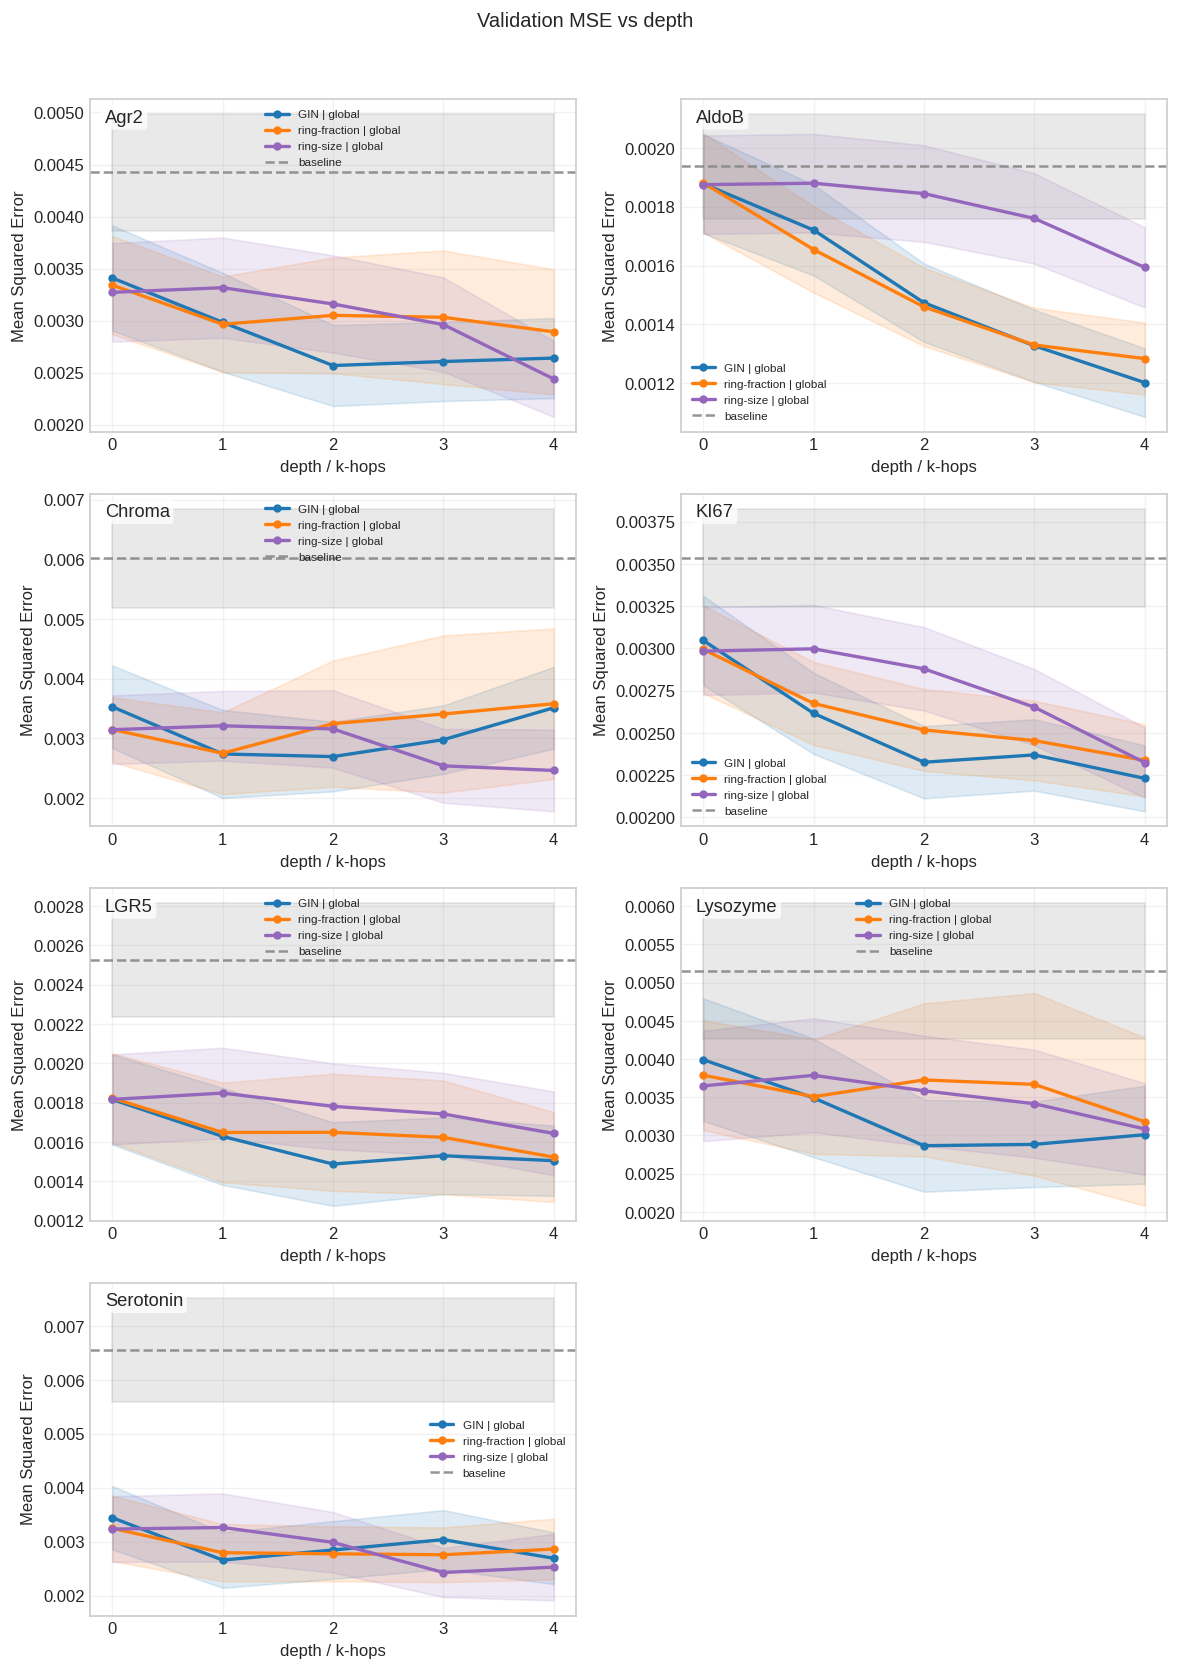

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604/figures/exp1_validation_mse_all_nodes_vs_depth.pdf


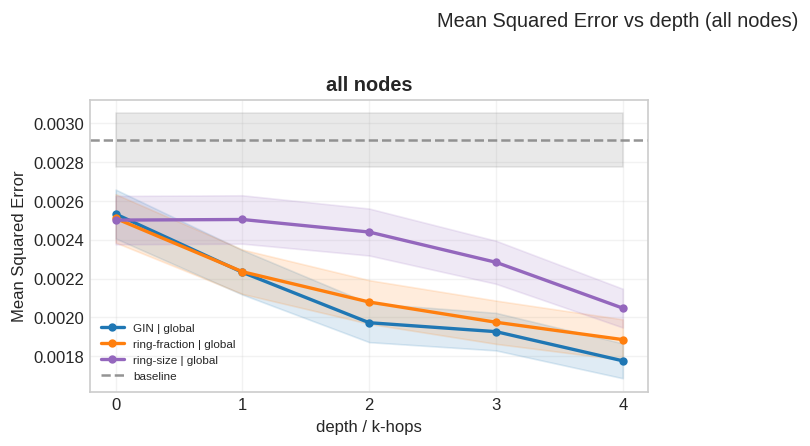

In [14]:
from src.plotting.depth_scan import plot_markerwise_metric_vs_depth, plot_all_aggregates_metric_vs_depth

fig, axes = plot_markerwise_metric_vs_depth(
    all_results=all_results_exp1,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Validation MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp1_validation_mse_markerwise_vs_depth")
plt.show()

fig, axes = plot_all_aggregates_metric_vs_depth(
    all_results_exp1,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Mean Squared Error vs depth (all nodes)",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp1_validation_mse_all_nodes_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604/figures/exp1_validation_nll_markerwise_vs_depth.pdf


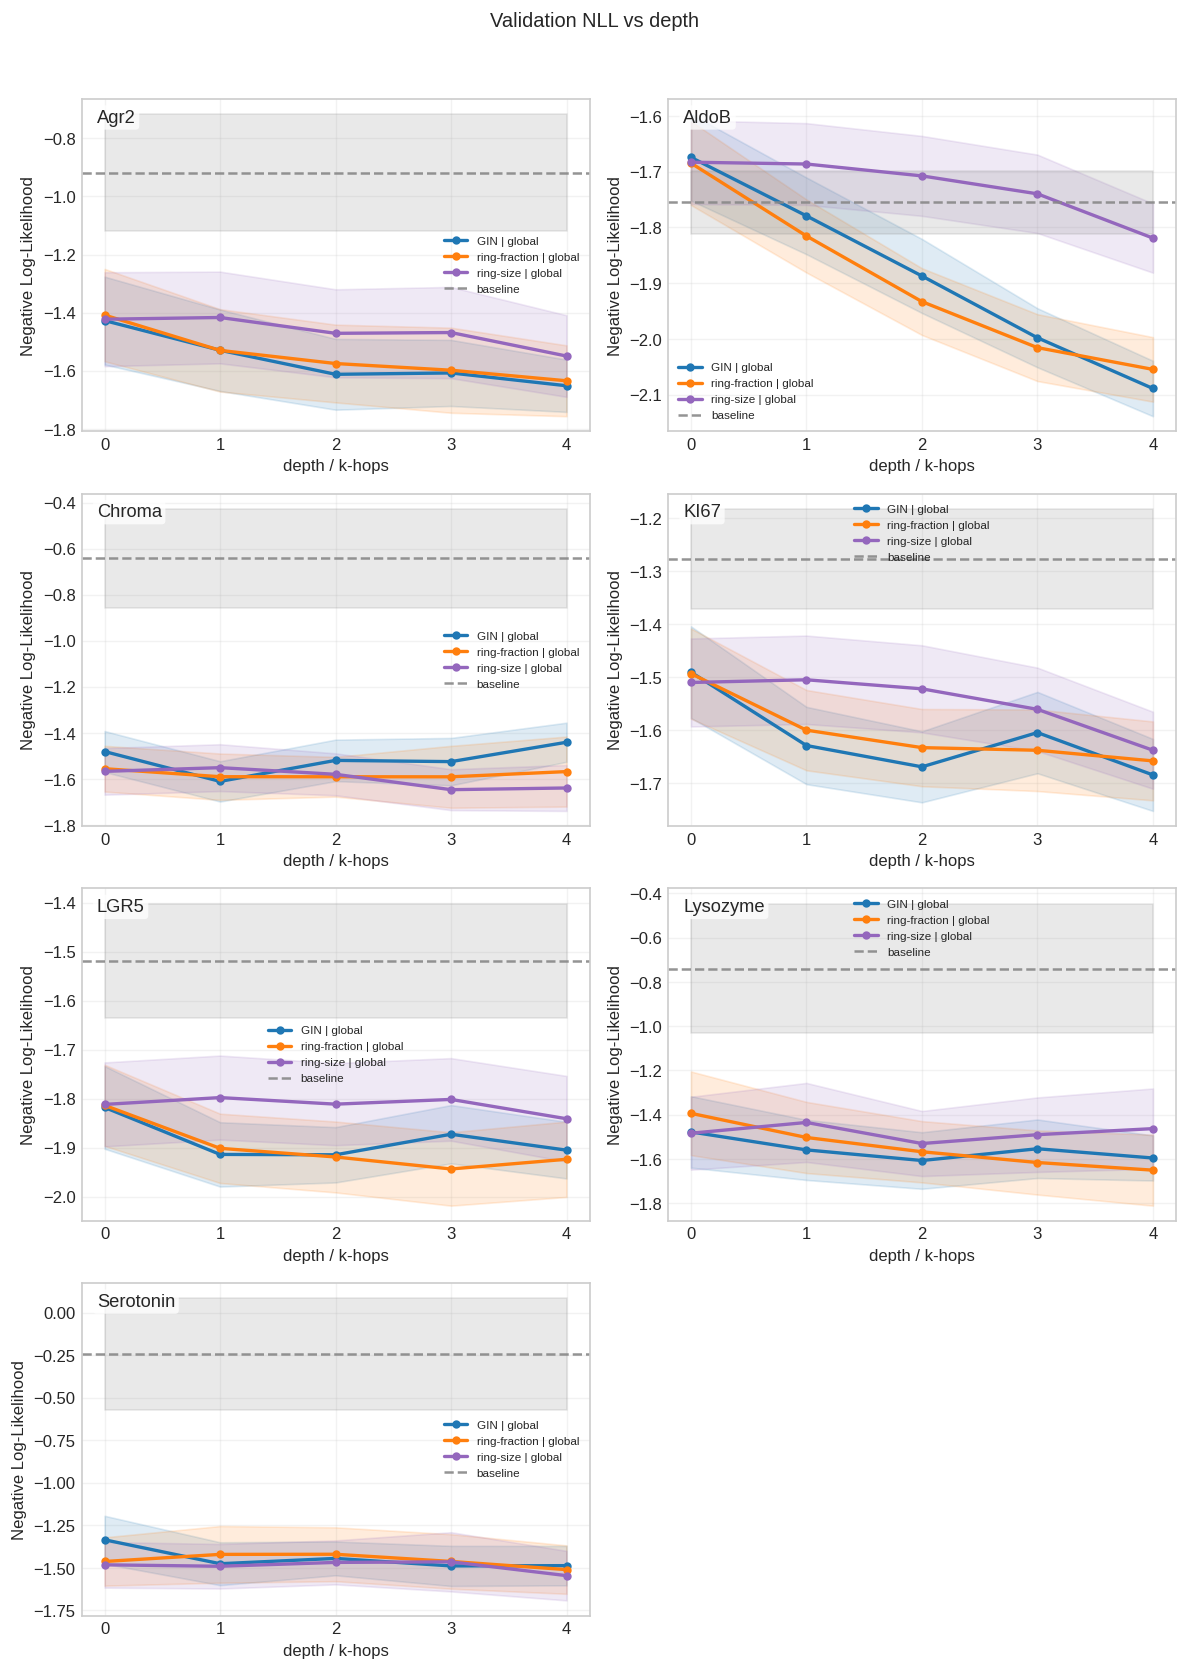

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604/figures/exp1_validation_nll_all_nodes_vs_depth.pdf


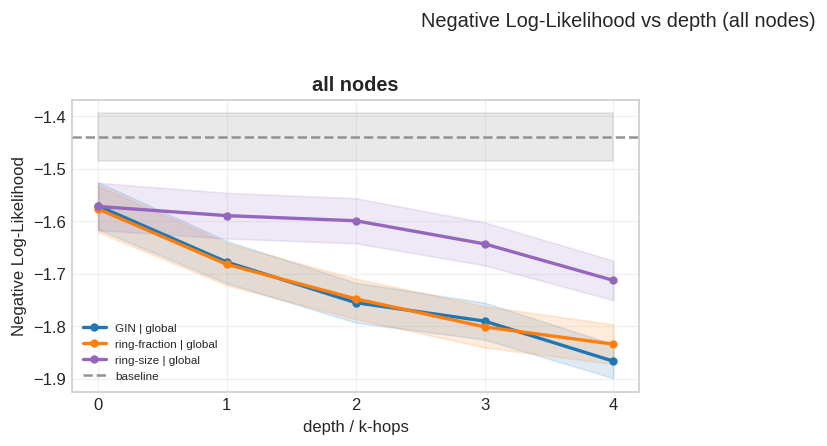

In [15]:
from src.plotting.depth_scan import plot_markerwise_metric_vs_depth, plot_all_aggregates_metric_vs_depth

fig, axes = plot_markerwise_metric_vs_depth(
    all_results=all_results_exp1,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Validation NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp1_validation_nll_markerwise_vs_depth")
plt.show()

fig, axes = plot_all_aggregates_metric_vs_depth(
    all_results_exp1,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Negative Log-Likelihood vs depth (all nodes)",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp1_validation_nll_all_nodes_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604/figures/exp1_uncertainty_error_correlation_markerwise_vs_depth.pdf


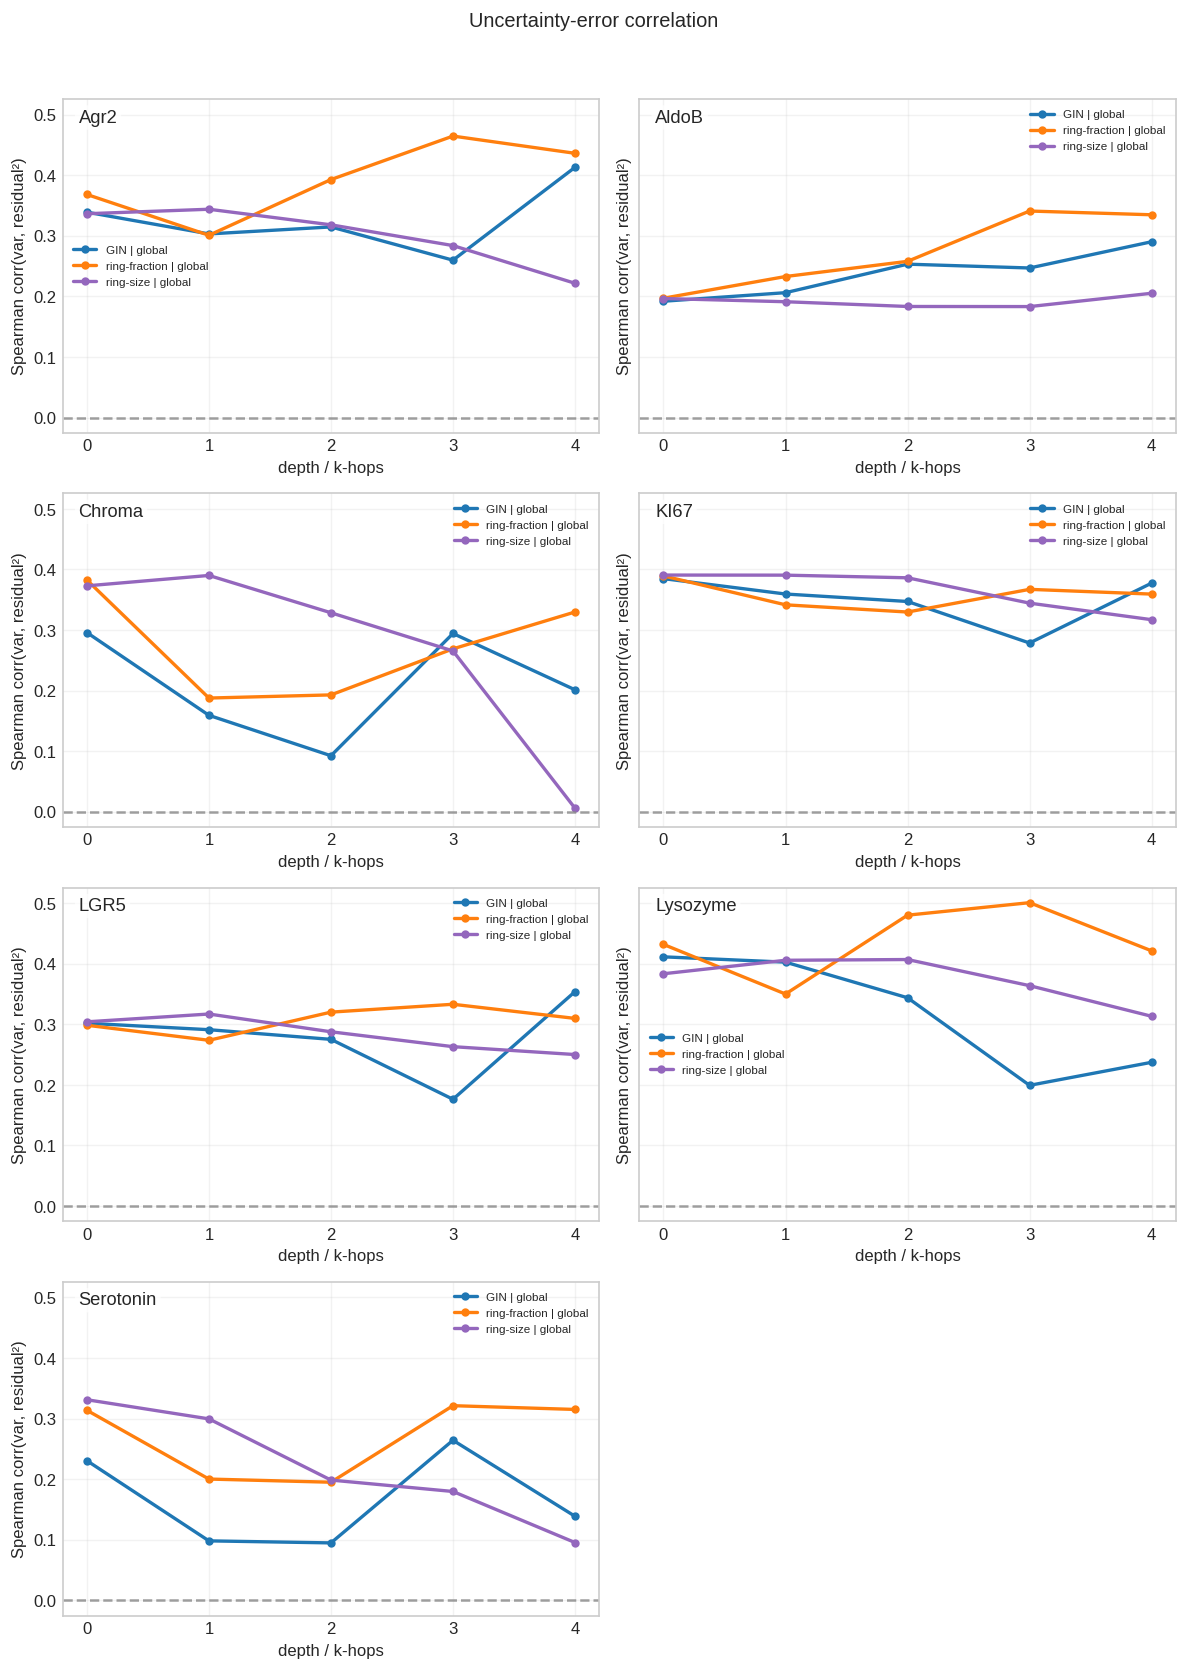

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604/figures/exp1_uncertainty_error_correlation_all_nodes_vs_depth.pdf


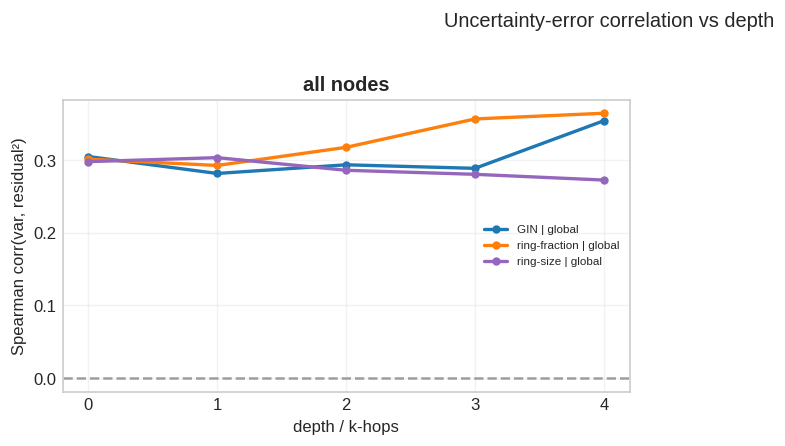

In [16]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=all_results_exp1,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="rho_marker",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation",
    family_order=family_order,
    family_colors=family_colors,
    sharey=True,
)
save_mpl_figure(fig, "exp1_uncertainty_error_correlation_markerwise_vs_depth")
plt.show()

fig, axes = plot_all_aggregates_metric_vs_depth(
    all_results_exp1,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="rho",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp1_uncertainty_error_correlation_all_nodes_vs_depth")
plt.show()


## Experiment 2: Full within-organoid marker permutation

We train a separate model grid on fully marker-permuted training graphs and evaluate it on fully marker-permuted validation subgraphs rebuilt at the same sampled centers. This matches the full feature permutation used in `permutations_tests.ipynb`: target values and organoid-level metadata are left unchanged, while node-marker alignment is destroyed.


In [17]:
from src.data.permutation import permute_graph_features_within_organoid
from src.data.subgraph_sampling import center_specs_from_subgraphs
from src.data.subgraphs import build_ego_subgraphs_for_center_specs


def permute_graph_features_and_recompute_ring_features(train_graphs, val_graphs, *, seed):
    generator = torch.Generator(device="cpu")
    generator.manual_seed(int(seed))
    g_train_perm = permute_graph_features_within_organoid(
        train_graphs,
        inplace=False,
        generator=generator,
    )
    g_val_perm = permute_graph_features_within_organoid(
        val_graphs,
        inplace=False,
        generator=generator,
    )
    g_train_perm = attach_precomputed_ring_features(
        g_train_perm,
        k_hops=K_MAX,
        inplace=False,
    )
    g_val_perm = attach_precomputed_ring_features(
        g_val_perm,
        k_hops=K_MAX,
        inplace=False,
    )
    return g_train_perm, g_val_perm


def build_subgraphs_for_sampled_centers(graphs, sampled_subgraphs, *, num_hops):
    center_specs = center_specs_from_subgraphs(sampled_subgraphs)
    return build_ego_subgraphs_for_center_specs(
        graphs,
        center_specs,
        num_hops=int(num_hops),
    )


full_permutation_variant_data = {}
full_permuted_val_subgraphs_by_variant = {}

for variant_name, pack in variant_data.items():
    g_train_perm, g_val_perm = permute_graph_features_and_recompute_ring_features(
        pack["g_train"],
        pack["g_val"],
        seed=FULL_PERMUTATION_SEED,
    )
    full_permutation_variant_data[variant_name] = {
        **pack,
        "g_train": g_train_perm,
        "g_val": g_val_perm,
    }
    full_permuted_val_subgraphs_by_variant[variant_name] = build_subgraphs_for_sampled_centers(
        g_val_perm,
        sampled_val_subgraphs_by_variant[variant_name],
        num_hops=K_MAX,
    )

trained_full_permutation_models_by_variant, full_permutation_training_logs = (
    train_model_grid_for_variant_packs(
        full_permutation_variant_data,
        label="fully_permuted",
    )
)

all_results_exp2_by_variant = {}
for variant_name, pack in full_permutation_variant_data.items():
    all_results_exp2_by_variant[variant_name] = evaluate_family_models(
        trained_models=trained_full_permutation_models_by_variant[variant_name],
        eval_subgraphs=full_permuted_val_subgraphs_by_variant[variant_name],
        device=device,
        target_transform=pack["target_transform"],
        center_only=True,
        baseline_metrics=baseline_metrics_by_variant[variant_name],
    )

all_results_exp2 = flatten_variant_results(all_results_exp2_by_variant)
print("Experiment 2 families:", list(all_results_exp2.keys()))



=== Training GIN | with_global | fully_permuted | depth=0 ===
epoch 001 | train loss 0.6297 mae 0.8576 | val loss 0.5473 mae 0.7945
epoch 002 | train loss 0.5829 mae 0.8251 | val loss 0.5227 mae 0.7731
epoch 003 | train loss 0.5533 mae 0.8003 | val loss 0.5032 mae 0.7575
epoch 004 | train loss 0.5317 mae 0.7829 | val loss 0.4873 mae 0.7461
epoch 005 | train loss 0.5156 mae 0.7709 | val loss 0.4746 mae 0.7381
epoch 006 | train loss 0.5043 mae 0.7632 | val loss 0.4647 mae 0.7324
epoch 007 | train loss 0.4968 mae 0.7581 | val loss 0.4571 mae 0.7281
epoch 008 | train loss 0.4912 mae 0.7539 | val loss 0.4514 mae 0.7249
epoch 009 | train loss 0.4864 mae 0.7509 | val loss 0.4472 mae 0.7227
epoch 010 | train loss 0.4824 mae 0.7488 | val loss 0.4440 mae 0.7212
epoch 011 | train loss 0.4790 mae 0.7473 | val loss 0.4414 mae 0.7202
epoch 012 | train loss 0.4759 mae 0.7461 | val loss 0.4378 mae 0.7194
epoch 013 | train loss 0.4730 mae 0.7455 | val loss 0.4348 mae 0.7188
epoch 014 | train loss 0.47

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604/figures/exp2_full_permutation_mse_markerwise_vs_depth.pdf


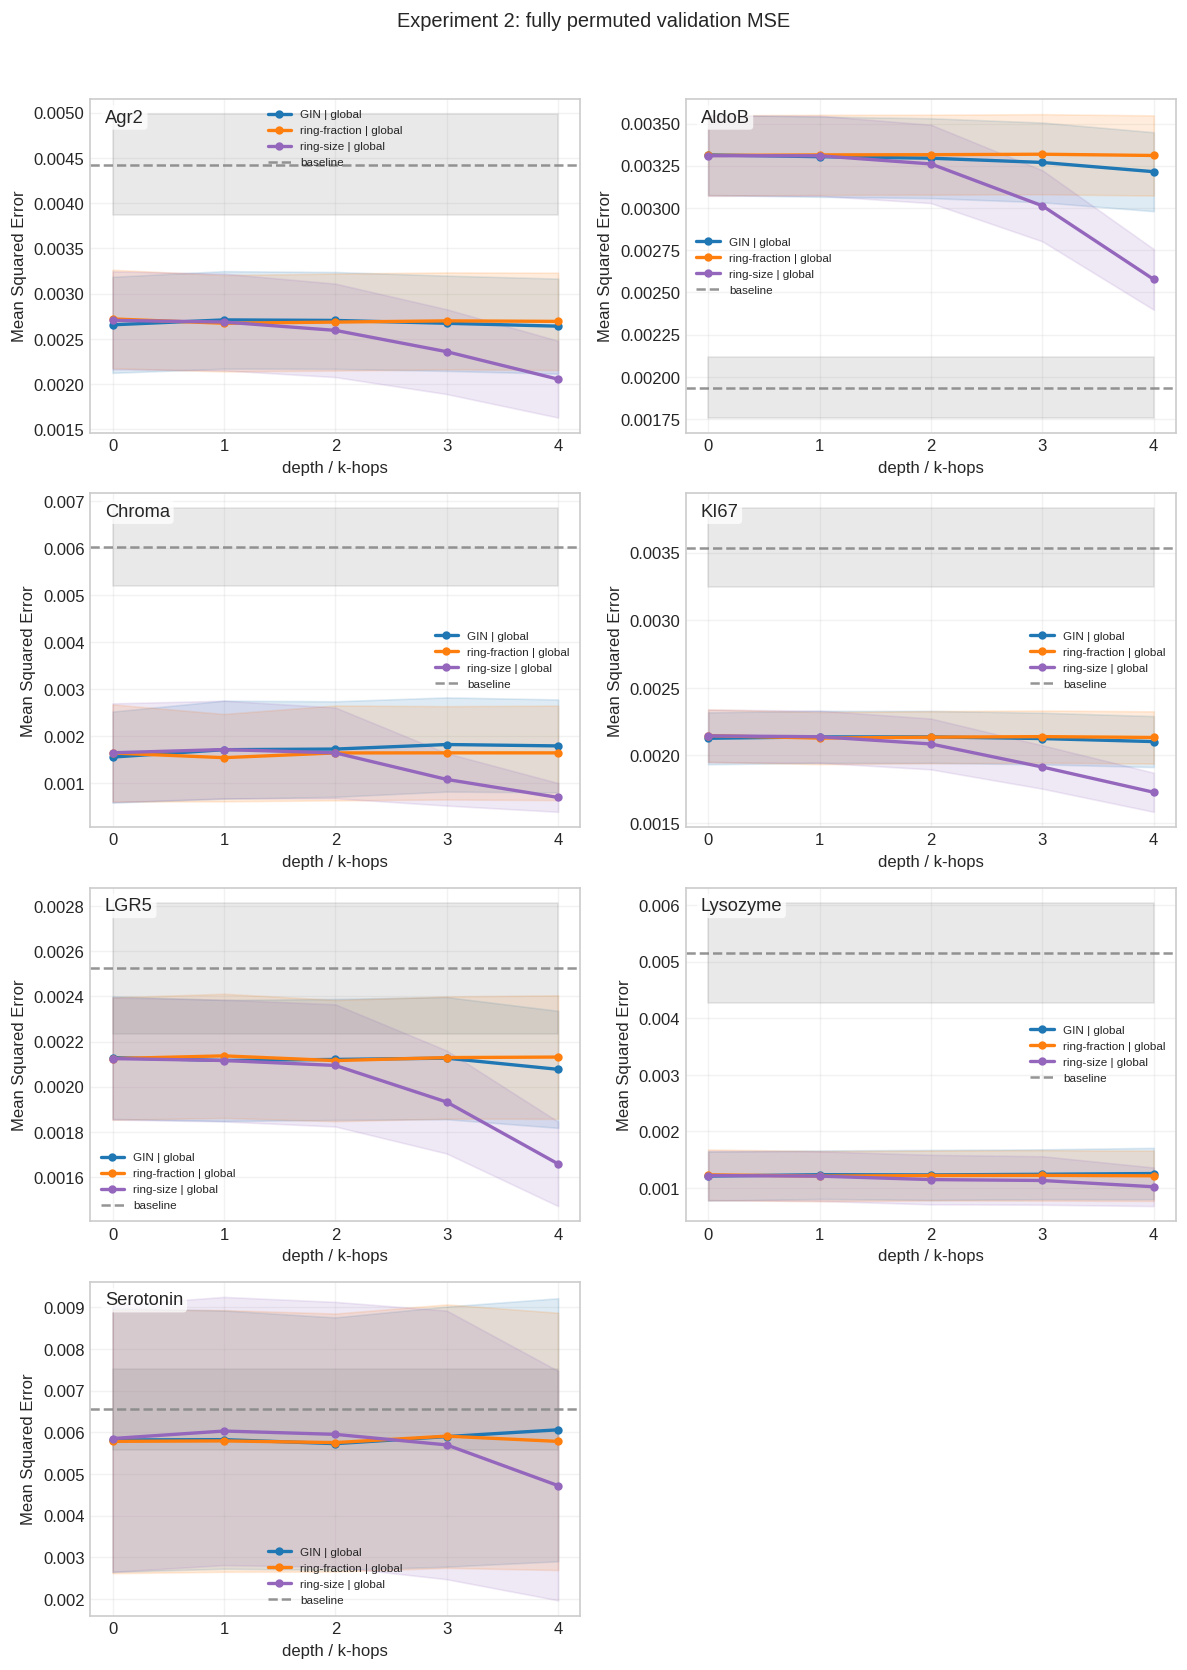

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604/figures/exp2_full_permutation_mse_all_nodes_vs_depth.pdf


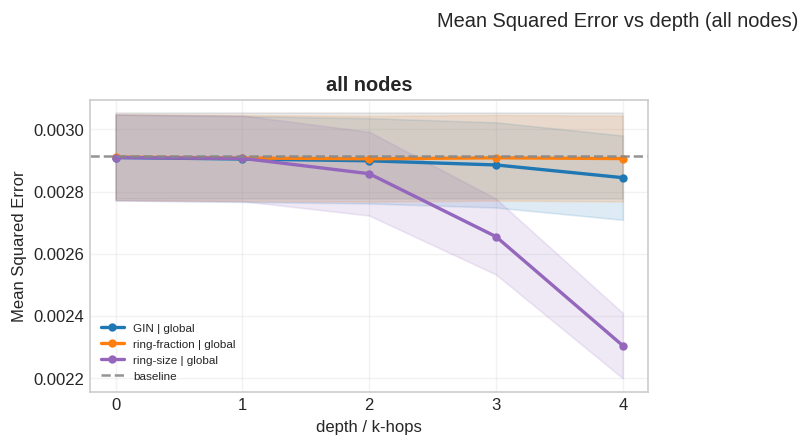

In [18]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=all_results_exp2,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Experiment 2: fully permuted validation MSE",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp2_full_permutation_mse_markerwise_vs_depth")
plt.show()

fig, axes = plot_all_aggregates_metric_vs_depth(
    all_results_exp2,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Mean Squared Error vs depth (all nodes)",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp2_full_permutation_mse_all_nodes_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604/figures/exp2_full_permutation_nll_markerwise_vs_depth.pdf


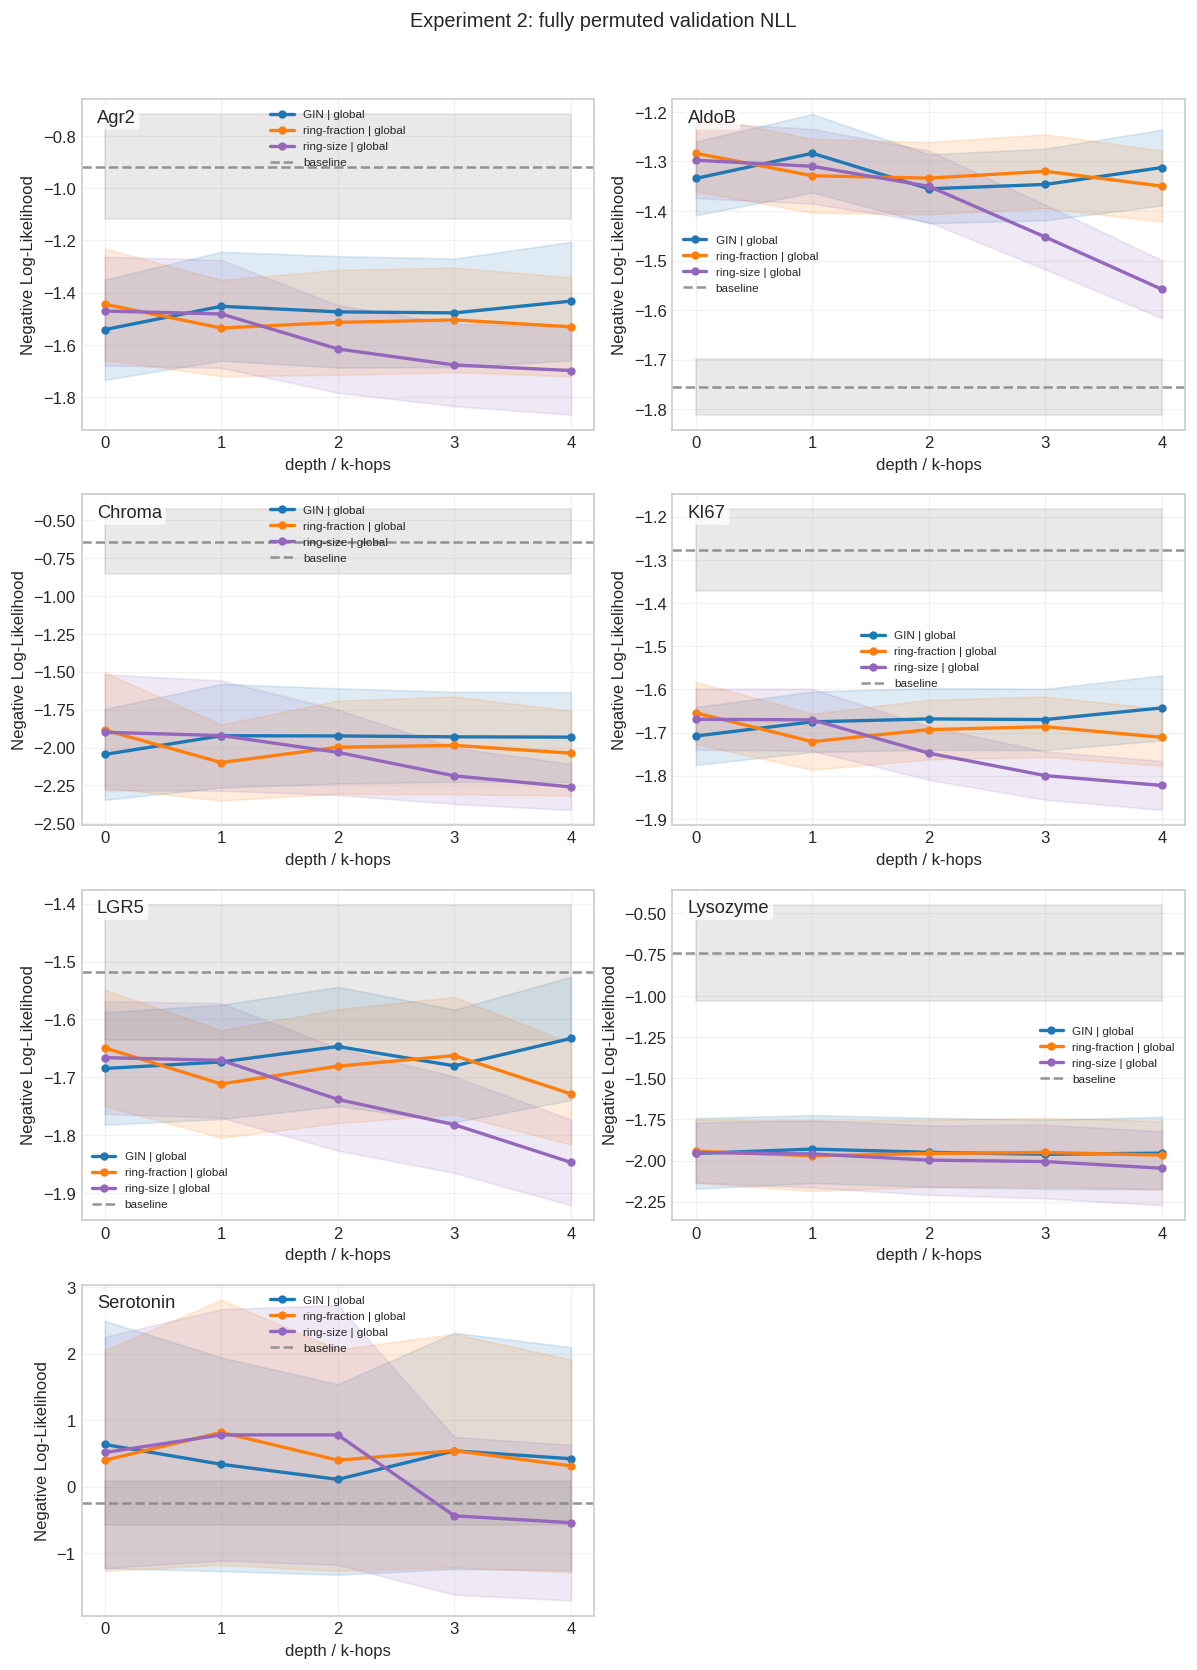

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604/figures/exp2_full_permutation_nll_all_nodes_vs_depth.pdf


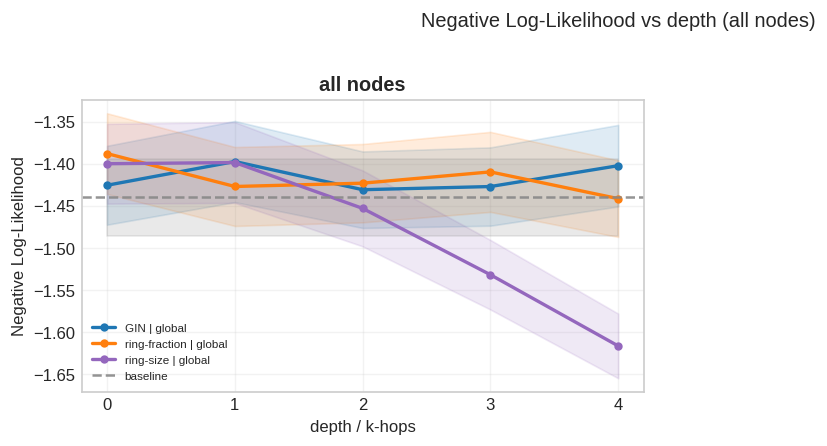

In [19]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=all_results_exp2,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Experiment 2: fully permuted validation NLL",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp2_full_permutation_nll_markerwise_vs_depth")
plt.show()

fig, axes = plot_all_aggregates_metric_vs_depth(
    all_results_exp2,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Negative Log-Likelihood vs depth (all nodes)",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp2_full_permutation_nll_all_nodes_vs_depth")
plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604/figures/exp2_uncertainty_error_correlation_markerwise_vs_depth.pdf


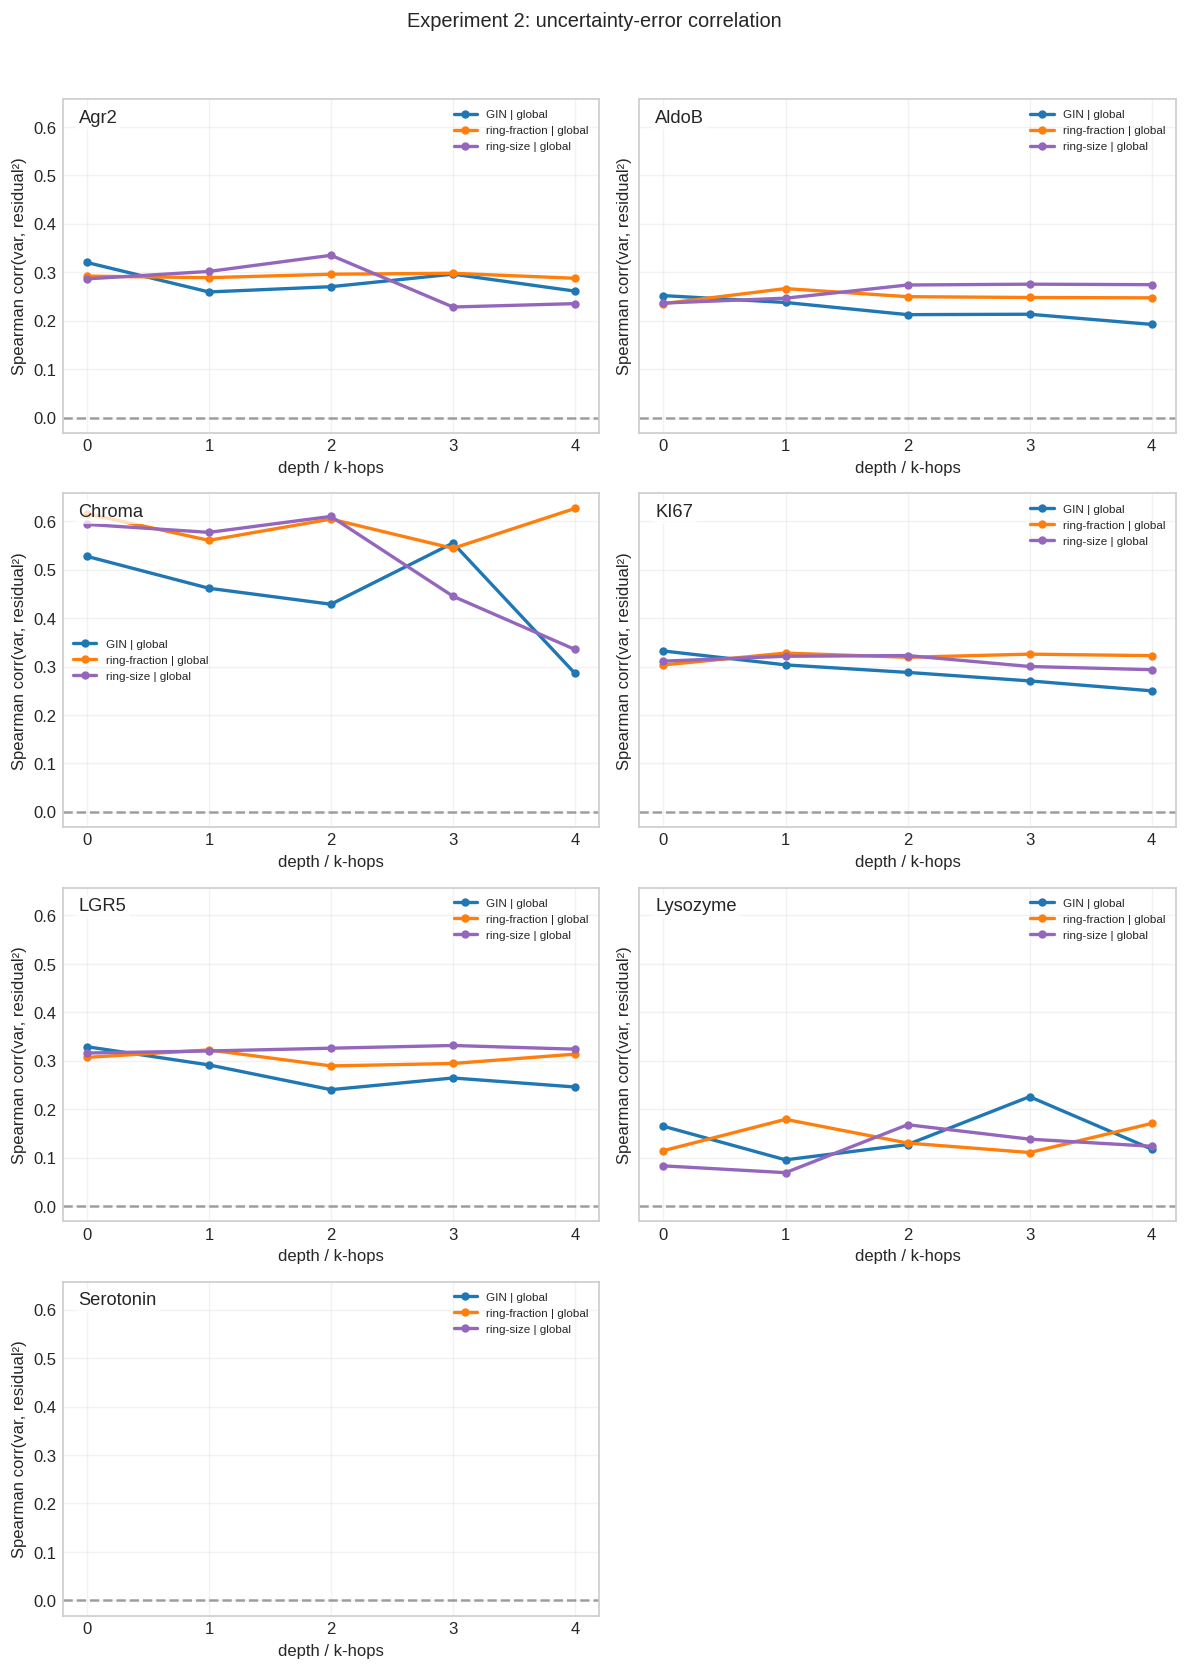

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604/figures/exp2_uncertainty_error_correlation_all_nodes_vs_depth.pdf


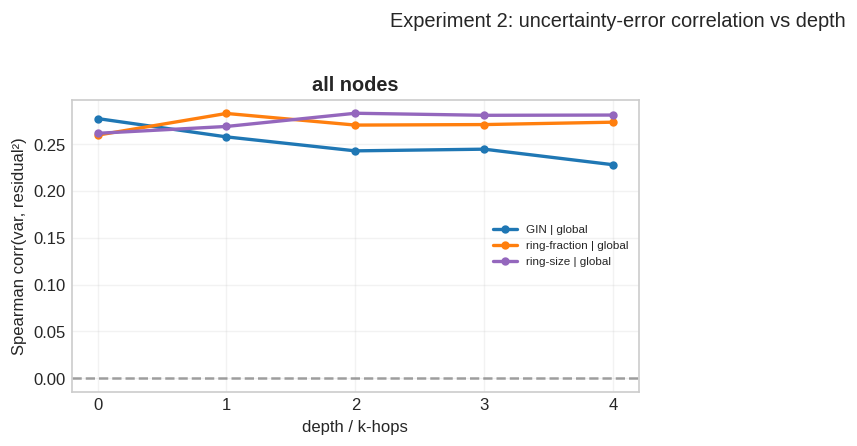

In [20]:
fig, axes = plot_markerwise_metric_vs_depth(
    all_results=all_results_exp2,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="rho_marker",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Experiment 2: uncertainty-error correlation",
    family_order=family_order,
    family_colors=family_colors,
    sharey=True,
)
save_mpl_figure(fig, "exp2_uncertainty_error_correlation_markerwise_vs_depth")
plt.show()

fig, axes = plot_all_aggregates_metric_vs_depth(
    all_results_exp2,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="rho",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Experiment 2: uncertainty-error correlation vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
save_mpl_figure(fig, "exp2_uncertainty_error_correlation_all_nodes_vs_depth")
plt.show()


## Experiment 3: Ring-preserving permutation

Here we evaluate all trained model families on validation subgraphs where marker features are permuted only within each k-hop ring around the center.


In [21]:
# ============================================================
# Experiment 3: ring-permuted validation subgraphs
# Evaluate ONLY GIN models, separately for each variant
# ============================================================

from src.data.permutation import permute_ego_neighborhood_within_rings

ring_permuted_val_subgraphs_by_variant = {}
all_results_exp3_by_variant = {}

for variant_name, pack in variant_data.items():
    ring_permuted_val_subgraphs = permute_ego_neighborhood_within_rings(
        sampled_val_subgraphs_by_variant[variant_name],
        k_hops=K_MAX,
    )
    ring_permuted_val_subgraphs_by_variant[variant_name] = ring_permuted_val_subgraphs

    gin_only_models = {
        family_name: model_family
        for family_name, model_family in trained_models_by_variant[variant_name].items()
        if "GIN" in family_name
    }

    if len(gin_only_models) == 0:
        raise ValueError(
            f"No GIN models found for variant {variant_name!r}. "
            f"Available families: {list(trained_models_by_variant[variant_name].keys())}"
        )

    all_results_exp3_by_variant[variant_name] = evaluate_family_models(
        trained_models=gin_only_models,
        eval_subgraphs=ring_permuted_val_subgraphs,
        device=device,
        target_transform=pack["target_transform"],
        center_only=True,
        baseline_metrics=baseline_metrics_by_variant[variant_name],
    )

all_results_exp3 = flatten_variant_results(all_results_exp3_by_variant)
print("Experiment 3 families:", list(all_results_exp3.keys()))

Experiment 3 families: ['GIN | global']


In [22]:
import math

def plot_two_result_sets_one_family(
    results_a,
    results_b,
    family,
    metric_key,
    sem_key=None,
    baseline_key=None,
    baseline_sem_key=None,
    ylabel="",
    title="",
    label_a="original",
    label_b="ring-permuted",
    color_a="#1f77b4",
    color_b="#d62728",
):
    n_markers = len(marker_names)
    n_cols = 2
    n_rows = math.ceil(n_markers / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3.2 * n_rows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, mi, mname in zip(axes, range(n_markers), marker_names):
        y_a = results_a[family][metric_key][:, mi]
        y_b = results_b[family][metric_key][:, mi]

        ax.plot(DEPTHS, y_a, "-o", color=color_a, linewidth=2, markersize=4, label=label_a)
        ax.plot(DEPTHS, y_b, "-o", color=color_b, linewidth=2, markersize=4, label=label_b)

        if sem_key is not None:
            s_a = results_a[family][sem_key][:, mi]
            s_b = results_b[family][sem_key][:, mi]
            ax.fill_between(DEPTHS, y_a - s_a, y_a + s_a, color=color_a, alpha=0.15)
            ax.fill_between(DEPTHS, y_b - s_b, y_b + s_b, color=color_b, alpha=0.15)

        if baseline_key is not None:
            y0 = results_a[family][baseline_key][mi]
            ax.axhline(y0, linestyle="--", color="#888888", alpha=0.8, label="baseline")

            if baseline_sem_key is not None:
                s0 = results_a[family][baseline_sem_key][mi]
                ax.fill_between(DEPTHS, y0 - s0, y0 + s0, color="#888888", alpha=0.12)

        ax.set_title(mname)
        ax.set_xlabel("depth / k-hops")
        ax.set_ylabel(ylabel)
        ax.set_xticks(DEPTHS)
        ax.legend(fontsize=7)

    for ax in axes[n_markers:]:
        ax.set_visible(False)

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    return fig


def plot_two_result_sets_one_family_aggregate(
    results_a,
    results_b,
    family,
    depths,
    *,
    aggregate_key="all_nodes",
    metric_key,
    sem_key=None,
    baseline_key=None,
    baseline_sem_key=None,
    ylabel="",
    title="",
    label_a="original",
    label_b="ring-permuted",
    color_a="#1f77b4",
    color_b="#d62728",
    baseline_color="#888888",
    legend_fontsize=8,
    fill_alpha=0.15,
    baseline_fill_alpha=0.12,
    figsize=(7, 4),
):
    if family not in results_a:
        raise KeyError(f"{family!r} not found in results_a")
    if family not in results_b:
        raise KeyError(f"{family!r} not found in results_b")

    x = np.asarray(depths)

    fig, ax = plt.subplots(figsize=figsize)

    y_a = np.asarray(results_a[family]["aggregate"][aggregate_key][metric_key], dtype=float)
    y_b = np.asarray(results_b[family]["aggregate"][aggregate_key][metric_key], dtype=float)

    ax.plot(x, y_a, "-o", color=color_a, linewidth=2, markersize=4, label=label_a)
    ax.plot(x, y_b, "-o", color=color_b, linewidth=2, markersize=4, label=label_b)

    if sem_key is not None:
        s_a = np.asarray(results_a[family]["aggregate"][aggregate_key][sem_key], dtype=float)
        s_b = np.asarray(results_b[family]["aggregate"][aggregate_key][sem_key], dtype=float)

        ax.fill_between(x, y_a - s_a, y_a + s_a, color=color_a, alpha=fill_alpha)
        ax.fill_between(x, y_b - s_b, y_b + s_b, color=color_b, alpha=fill_alpha)

    if baseline_key is not None:
        y0 = results_a[family]["aggregate"][aggregate_key][baseline_key]
        y0 = float(y0[0]) if np.ndim(y0) > 0 else float(y0)

        ax.axhline(y0, linestyle="--", color=baseline_color, alpha=0.8, label="baseline")

        if baseline_sem_key is not None:
            s0 = results_a[family]["aggregate"][aggregate_key][baseline_sem_key]
            s0 = float(s0[0]) if np.ndim(s0) > 0 else float(s0)

            ax.fill_between(x, y0 - s0, y0 + s0, color=baseline_color, alpha=baseline_fill_alpha)

    pretty_names = {
        "all_nodes": "all nodes",
        "any_marker": "marker-positive nodes",
        "no_marker": "marker-negative nodes",
    }

    ax.set_title(pretty_names.get(aggregate_key, aggregate_key))
    ax.set_xlabel("depth / k-hops")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.legend(fontsize=legend_fontsize)

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    return fig, ax

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604/figures/exp3_GIN_global_original_vs_ring_permuted_markerwise_mse.pdf


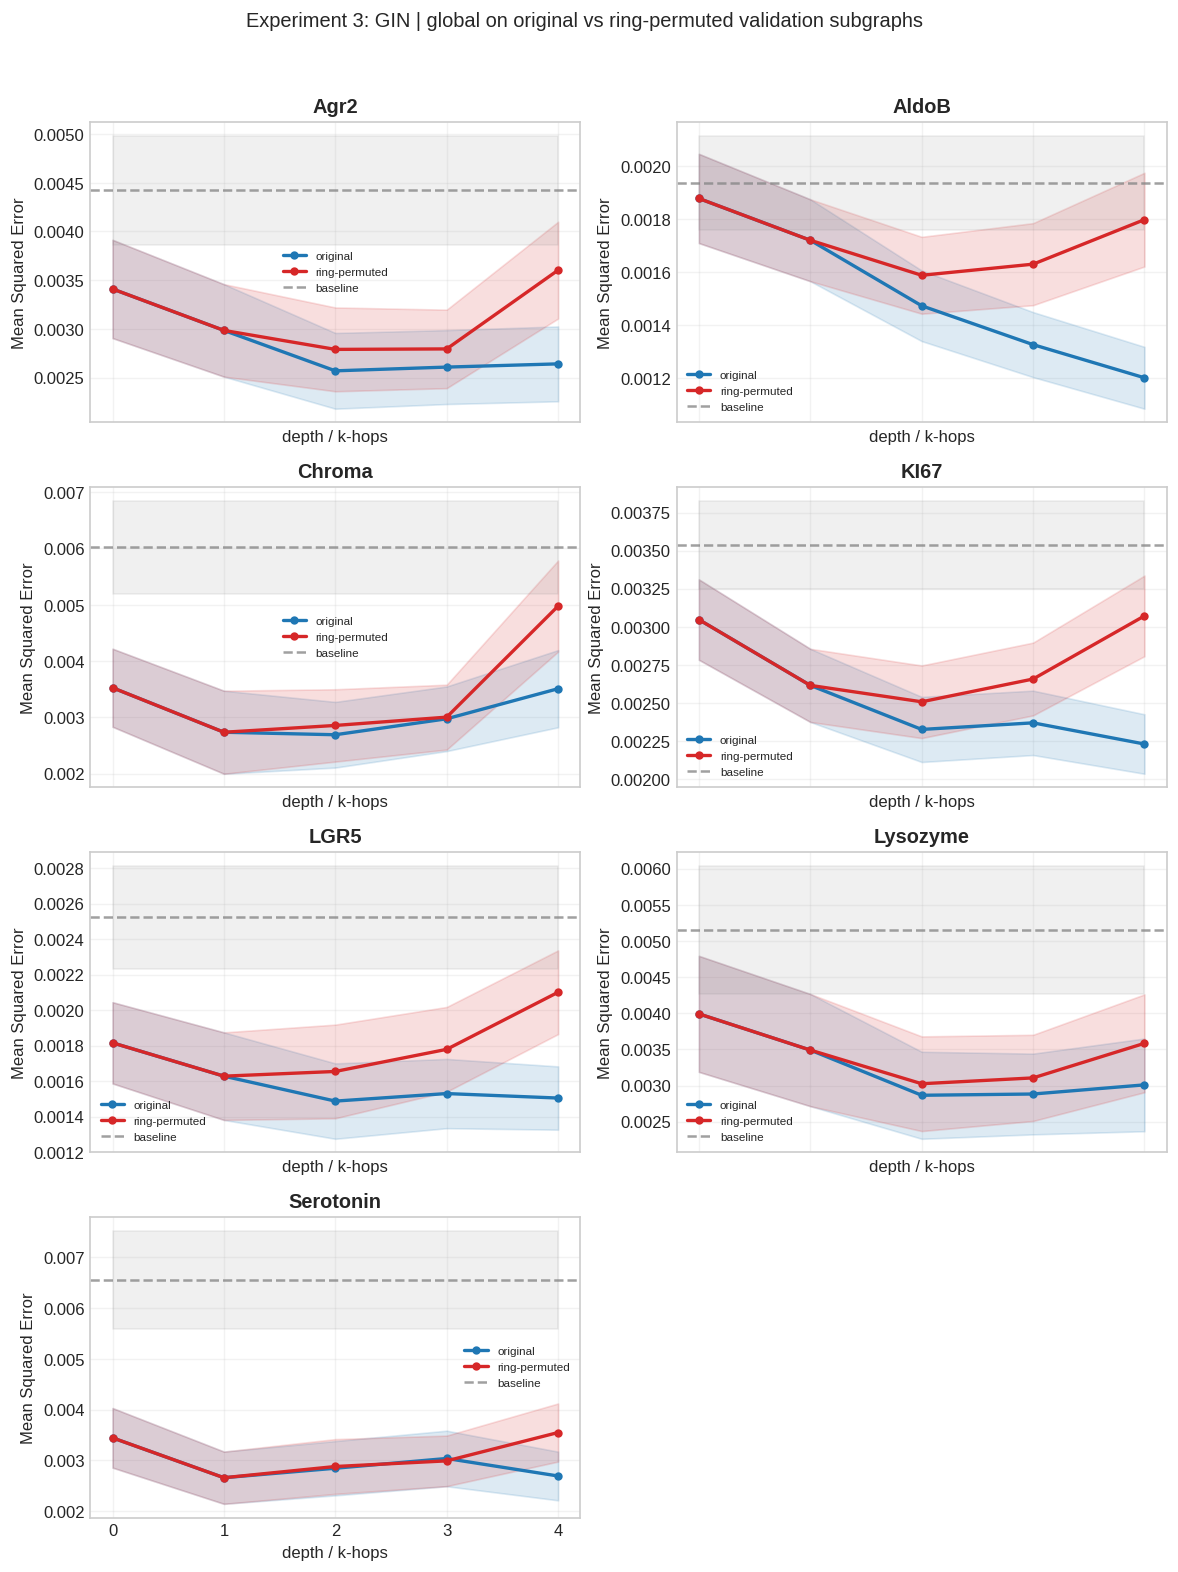

In [23]:
gin_families_exp3 = [family for family in all_results_exp3.keys() if "GIN" in family]

for family in gin_families_exp3:
    fig = plot_two_result_sets_one_family(
        all_results_exp1,
        all_results_exp3,
        family=family,
        metric_key="mse_model",
        sem_key="sem_mse_model",
        baseline_key="mse_base",
        baseline_sem_key="sem_mse_base",
        ylabel="Mean Squared Error",
        title=f"Experiment 3: {family} on original vs ring-permuted validation subgraphs",
        label_a="original",
        label_b="ring-permuted",
    )
    save_mpl_figure(fig, f"exp3_{family}_original_vs_ring_permuted_markerwise_mse")
    plt.show()


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604/figures/exp3_GIN_global_original_vs_ring_permuted_all_nodes_mse.pdf


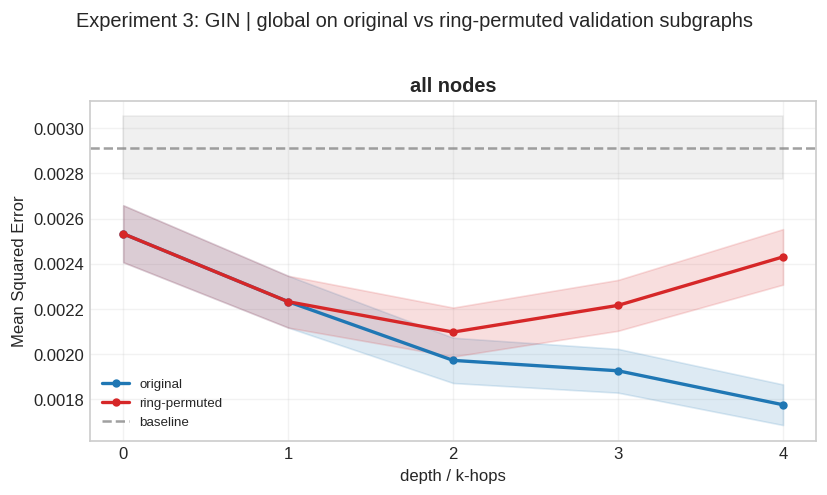

In [24]:
gin_families_exp3 = [family for family in all_results_exp3.keys() if "GIN" in family]

for family in gin_families_exp3:
    for aggregate_key in ["all_nodes"]:
        fig, ax = plot_two_result_sets_one_family_aggregate(
            all_results_exp1,
            all_results_exp3,
            family=family,
            depths=DEPTHS,
            aggregate_key=aggregate_key,
            metric_key="mse_model",
            sem_key="sem_mse_model",
            baseline_key="mse_base",
            baseline_sem_key="sem_mse_base",
            ylabel="Mean Squared Error",
            title=f"Experiment 3: {family} on original vs ring-permuted validation subgraphs",
            label_a="original",
            label_b="ring-permuted",
        )
        save_mpl_figure(fig, f"exp3_{family}_original_vs_ring_permuted_{aggregate_key}_mse")
        plt.show()


## Summarize results

In [25]:
EXPERIMENT_RESULTS_FLAT = {
    "exp1_original": all_results_exp1,
    "exp2_fully_permuted": all_results_exp2,
    "exp3_ring_preserving_permuted": all_results_exp3,
}

MARKERWISE_MODEL_METRICS = [
    "mse_model",
    "sem_mse_model",
    "var_model",
    "sem_var_model",
    "nll_model",
    "sem_nll_model",
    "rho_marker",
    "pval_marker",
    "n_pos_corr",
]
MARKERWISE_BASELINE_METRICS = [
    "mse_base",
    "sem_mse_base",
    "var_base",
    "nll_base",
    "sem_nll_base",
]
GLOBAL_METRICS = ["rho_global", "pval_global"]


def split_family_label(family_label):
    parts = [part.strip() for part in str(family_label).split("|")]
    if len(parts) == 2:
        return parts[0], parts[1]
    return str(family_label), ""


def summarize_results(flat_results, *, experiment_name, depths):
    rows = []
    for family_label, res in flat_results.items():
        model_family, feature_variant = split_family_label(family_label)
        for depth_idx, depth in enumerate(depths):
            row = {
                "experiment": experiment_name,
                "family": family_label,
                "model_family": model_family,
                "feature_variant": feature_variant,
                "depth": int(depth),
                "mse_all_nodes": float(res["aggregate"]["all_nodes"]["mse_model"][depth_idx]),
                "sem_mse_all_nodes": float(res["aggregate"]["all_nodes"]["sem_mse_model"][depth_idx]),
                "mse_base_all_nodes": float(res["aggregate"]["all_nodes"]["mse_base"][depth_idx]),
                "sem_mse_base_all_nodes": float(res["aggregate"]["all_nodes"]["sem_mse_base"][depth_idx]),
                "nll_all_nodes": float(res["aggregate"]["all_nodes"]["nll_model"][depth_idx]),
                "sem_nll_all_nodes": float(res["aggregate"]["all_nodes"]["sem_nll_model"][depth_idx]),
                "nll_base_all_nodes": float(res["aggregate"]["all_nodes"]["nll_base"][depth_idx]),
                "sem_nll_base_all_nodes": float(res["aggregate"]["all_nodes"]["sem_nll_base"][depth_idx]),
                "rho_all_nodes": float(res["aggregate"]["all_nodes"]["rho"][depth_idx]),
                "pval_all_nodes": float(res["aggregate"]["all_nodes"]["pval"][depth_idx]),
            }
            rows.append(row)
    return pd.DataFrame(rows)


def flatten_markerwise_results(experiment_results, *, depths, marker_names_in):
    rows = []
    for experiment_name, flat_results in experiment_results.items():
        for family_label, res in flat_results.items():
            model_family, feature_variant = split_family_label(family_label)
            for depth_idx, depth in enumerate(depths):
                for marker_idx, marker_name in enumerate(marker_names_in):
                    row = {
                        "experiment": experiment_name,
                        "family": family_label,
                        "model_family": model_family,
                        "feature_variant": feature_variant,
                        "depth": int(depth),
                        "marker_index": int(marker_idx),
                        "marker": marker_name,
                    }
                    for metric in MARKERWISE_MODEL_METRICS:
                        if metric in res:
                            row[metric] = float(np.asarray(res[metric])[depth_idx, marker_idx])
                    for metric in MARKERWISE_BASELINE_METRICS:
                        if metric in res:
                            row[metric] = float(np.asarray(res[metric])[marker_idx])
                    rows.append(row)
    return pd.DataFrame(rows)


def flatten_aggregate_results(experiment_results, *, depths):
    rows = []
    for experiment_name, flat_results in experiment_results.items():
        for family_label, res in flat_results.items():
            model_family, feature_variant = split_family_label(family_label)
            for aggregate_name, aggregate_metrics in res["aggregate"].items():
                for depth_idx, depth in enumerate(depths):
                    row = {
                        "experiment": experiment_name,
                        "family": family_label,
                        "model_family": model_family,
                        "feature_variant": feature_variant,
                        "aggregate": aggregate_name,
                        "depth": int(depth),
                    }
                    for metric, values in aggregate_metrics.items():
                        row[metric] = float(np.asarray(values)[depth_idx])
                    rows.append(row)
    return pd.DataFrame(rows)


def flatten_global_results(experiment_results, *, depths):
    rows = []
    for experiment_name, flat_results in experiment_results.items():
        for family_label, res in flat_results.items():
            model_family, feature_variant = split_family_label(family_label)
            for depth_idx, depth in enumerate(depths):
                row = {
                    "experiment": experiment_name,
                    "family": family_label,
                    "model_family": model_family,
                    "feature_variant": feature_variant,
                    "depth": int(depth),
                }
                for metric in GLOBAL_METRICS:
                    if metric in res:
                        row[metric] = float(np.asarray(res[metric])[depth_idx])
                rows.append(row)
    return pd.DataFrame(rows)


summary_df = pd.concat(
    [
        summarize_results(results, experiment_name=experiment, depths=DEPTHS)
        for experiment, results in EXPERIMENT_RESULTS_FLAT.items()
    ],
    ignore_index=True,
)
markerwise_results_df = flatten_markerwise_results(
    EXPERIMENT_RESULTS_FLAT,
    depths=DEPTHS,
    marker_names_in=marker_names,
)
aggregate_results_df = flatten_aggregate_results(
    EXPERIMENT_RESULTS_FLAT,
    depths=DEPTHS,
)
global_results_df = flatten_global_results(
    EXPERIMENT_RESULTS_FLAT,
    depths=DEPTHS,
)

summary_df.sort_values(["experiment", "family", "depth"]).head(20)


,experiment,family,model_family,feature_variant,depth,mse_all_nodes,sem_mse_all_nodes,mse_base_all_nodes,sem_mse_base_all_nodes,nll_all_nodes,sem_nll_all_nodes,nll_base_all_nodes,sem_nll_base_all_nodes,rho_all_nodes,pval_all_nodes
0,exp1_original,GIN | global,GIN,global,0,0.002533,0.000126,0.002913,0.000139,-1.570619,0.044972,-1.440082,0.045871,0.304767,6.902409e-55
1,exp1_original,GIN | global,GIN,global,1,0.002232,0.000115,0.002913,0.000139,-1.677661,0.040205,-1.440082,0.045871,0.281499,9.324298e-47
2,exp1_original,GIN | global,GIN,global,2,0.001973,0.000100,0.002913,0.000139,-1.754847,0.038045,-1.440082,0.045871,0.293396,8.080988e-51
3,exp1_original,GIN | global,GIN,global,3,0.001927,0.000097,0.002913,0.000139,-1.790005,0.035108,-1.440082,0.045871,0.288527,3.925043e-49
4,exp1_original,GIN | global,GIN,global,4,0.001776,0.000090,0.002913,0.000139,-1.866368,0.032477,-1.440082,0.045871,0.353958,1.105213e-74
5,exp1_original,ring-fraction | global,ring-fraction,global,0,0.002510,0.000125,0.002913,0.000139,-1.576380,0.044522,-1.440082,0.045871,0.301185,1.382264e-53
6,exp1_original,ring-fraction | global,ring-fraction,global,1,0.002235,0.000114,0.002913,0.000139,-1.682021,0.039952,-1.440082,0.045871,0.292476,1.693168e-50
7,exp1_original,ring-fraction | global,ring-fraction,global,2,0.002079,0.000113,0.002913,0.000139,-1.747566,0.038438,-1.440082,0.045871,0.317413,1.247599e-59
8,exp1_original,ring-fraction | global,ring-fraction,global,3,0.001975,0.000112,0.002913,0.000139,-1.800991,0.039078,-1.440082,0.045871,0.356439,8.842183e-76
9,exp1_original,ring-fraction | global,ring-fraction,global,4,0.001886,0.000105,0.002913,0.000139,-1.833958,0.037744,-1.440082,0.045871,0.364254,2.667764e-79


## Save the results

In [26]:

def _jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [_jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, torch.dtype):
        return str(obj)
    if isinstance(obj, np.dtype):
        return str(obj)
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

def save_joint_experiment(save_dir, config, results_by_experiment, notes=None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "config.json", "w") as f:
        json.dump(_jsonable(config), f, indent=2)

    with open(save_dir / "results.pkl", "wb") as f:
        pickle.dump(results_by_experiment, f)

    meta = {
        "timestamp": datetime.now().isoformat(),
        "notes": notes,
        "experiments": list(results_by_experiment.keys()),
    }
    with open(save_dir / "meta.json", "w") as f:
        json.dump(_jsonable(meta), f, indent=2)

    print(f"Saved joint experiment -> {save_dir}")


In [27]:
save_dir = SAVE_DIR

RESULT_TABLE_FILES = {
    "summary_metrics": "summary_metrics.csv",
    "markerwise_metrics": "markerwise_metrics.csv",
    "aggregate_metrics": "aggregate_metrics.csv",
    "global_metrics": "global_metrics.csv",
}

summary_df.to_csv(TABLES_DIR / RESULT_TABLE_FILES["summary_metrics"], index=False)
markerwise_results_df.to_csv(
    TABLES_DIR / RESULT_TABLE_FILES["markerwise_metrics"], index=False
)
aggregate_results_df.to_csv(
    TABLES_DIR / RESULT_TABLE_FILES["aggregate_metrics"], index=False
)
global_results_df.to_csv(
    TABLES_DIR / RESULT_TABLE_FILES["global_metrics"], index=False
)


joint_config = {
    "created_at": RUN_TIMESTAMP,
    "experiment_group": EXPERIMENT_GROUP,
    "dataset": {
        "name": DATASET_NAME,
        "target_indices": TARGET_INDICES,
        "target_labels": TARGET_LABELS,
        "marker_names": list(marker_names),
    },
    "model_families": MODEL_FAMILIES,
    "use_global_features": USE_GLOBAL_FEATURES,
    "feature_variants": FEATURE_VARIANTS,
    "depths": DEPTHS.tolist(),
    "hidden_dim": BASE_HIDDEN_DIM,
    "dropout": BASE_DROPOUT,
    "norm": BASE_NORM,
    "K_MAX": K_MAX,
    "full_permutation_seed": FULL_PERMUTATION_SEED,
    "filtering": {
        "timepoint_filter_mode": TIMEPOINT_FILTER_MODE,
        "day3p5_timepoint": DAY3P5_TIMEPOINT,
        "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
        "blacklisted_organoids": sorted(blacklist, key=str),
        "fill_missing_complexity": FILL_MISSING_COMPLEXITY,
        "apply_complexity_filter": APPLY_COMPLEXITY_FILTER,
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "complexity_min": COMPLEXITY_MIN,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
        "n_graphs_after_filtering": len(graphs),
    },
    "split": {
        "val_frac": VAL_FRAC,
        "split_seed": SPLIT_SEED,
        "forced_val_keys": sorted(FORCED_VAL_KEYS, key=str),
        "n_train_graphs": len(base_train),
        "n_val_graphs": len(base_val),
        "split_info": split_info,
    },
    "field_specs": field_specs,
    "baseline_model": {
        "class": "GlobalFeatureMLP",
        "hidden_dim": BASELINE_HIDDEN_DIM,
        "dropout": BASELINE_DROPOUT,
        "computed_once_per_variant": True,
        "reused_for_experiments": ["exp1_original", "exp2_fully_permuted", "exp3_ring_preserving_permuted"],
    },
    "baseline_train_config": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "aux_losses": [],
    },
    "train_config": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_params": {
            "weight": EDGE_LOSS_WEIGHT,
            "weighted": False,
            "alpha": 2.0,
            "normalize_by": "graph_std",
            "clip_weight": 4.0,
        },
    },
    "sampling": {
        "n_sampled_subgraphs_by_variant": {
            k: len(v) for k, v in sampled_val_subgraphs_by_variant.items()
        },
        "experiment_2": "models are trained on fully permuted training graphs and evaluated on fully permuted validation graphs at the sampled validation centers",
    },
    "outputs": {
        "save_dir": SAVE_DIR,
        "figures_dir": FIGURES_DIR,
        "tables_dir": TABLES_DIR,
        "result_tables": RESULT_TABLE_FILES,
        "results_pickle": "results.pkl",
    },
}

results_by_experiment = {
    "exp1_original": all_results_exp1_by_variant,
    "exp2_fully_permuted": all_results_exp2_by_variant,
    "exp3_ring_preserving_permuted": all_results_exp3_by_variant,
    "baseline_training_logs": baseline_training_logs,
    "baseline_metrics": baseline_metrics_by_variant,
    "training_logs": training_logs,
    "full_permutation_training_logs": full_permutation_training_logs,
    "summary_table": summary_df.to_dict(orient="records"),
    "markerwise_metrics": markerwise_results_df.to_dict(orient="records"),
    "aggregate_metrics": aggregate_results_df.to_dict(orient="records"),
    "global_metrics": global_results_df.to_dict(orient="records"),
}

save_joint_experiment(
    save_dir=save_dir,
    config=joint_config,
    results_by_experiment=results_by_experiment,
    notes=("Signal composition analysis on after_cleanup with complexity filtering disabled, learned global-feature baseline, and full train/eval feature permutation for experiment 2."),
)

with open(SAVE_DIR / "settings.json", "w") as handle:
    json.dump(_jsonable(joint_config), handle, indent=2)

print(f"Saved figures, tables, settings, and results to {SAVE_DIR}")


Saved joint experiment -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604
Saved figures, tables, settings, and results to /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/signal_composition_analysis/after_cleanup_rest_depths-0-1-2-3-4_20260722_164604
